# Proyecto Final Data Mining - CASEN 2024

Clasificación supervisada de pobreza por ingresos en hogares chilenos.

## 1. Configuración y carga de datos

En este bloque se importan las librerías necesarias, se fija una semilla para asegurar reproducibilidad y se configuran opciones básicas de visualización. Además, se carga la base limpia que será utilizada en el modelamiento.


In [1]:
# ============================================================
# BLOQUE 1: Configuración inicial y carga de datos
# ============================================================

# Librerías generales
import os
import random
import warnings

# Manipulación de datos y operaciones numéricas
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Función para mostrar tablas de forma más clara en el notebook
from IPython.display import display

# Prueba estadística para análisis de asociación entre variables categóricas
from scipy.stats import chi2_contingency

# Herramientas para partición, validación cruzada y preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelo de regresión logística
from sklearn.linear_model import LogisticRegression

# Métricas de evaluación para modelos de clasificación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Se omiten advertencias para mantener una salida más limpia en el notebook
warnings.filterwarnings("ignore")

# Semilla para asegurar reproducibilidad en los procesos aleatorios
SEED = 123
np.random.seed(SEED)
random.seed(SEED)

# Configuración para visualizar mejor las tablas de pandas
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Configuración general de los gráficos
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.autolayout": True
})

# Paleta de colores definida para mantener gráficos consistentes
PALETA = {
    "azul": "#2F6B9A",
    "celeste": "#74A9CF",
    "naranjo": "#F28E2B",
    "verde": "#59A14F",
    "rojo": "#E15759",
    "gris": "#4E5D6C"
}

# Conexión a Google Drive en caso de ejecutar el notebook en Google Colab
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Entorno local detectado. No se montó Google Drive.")

# Rutas principales del proyecto
ruta_proyecto = "/content/drive/MyDrive/DataMining_CASEN2024"
ruta_datos_procesados = os.path.join(ruta_proyecto, "datos_procesados")

# Rutas posibles de la base procesada
ruta_parquet = os.path.join(ruta_datos_procesados, "casen2024_modelamiento.parquet")
ruta_csv = os.path.join(ruta_datos_procesados, "casen2024_modelamiento.csv")

# Carga de la base limpia desde Parquet o CSV, según el archivo disponible
if os.path.exists(ruta_parquet):
    df = pd.read_parquet(ruta_parquet)
    print("Base cargada desde archivo Parquet.")
elif os.path.exists(ruta_csv):
    df = pd.read_csv(ruta_csv)
    print("Base cargada desde archivo CSV.")
else:
    raise FileNotFoundError("No se encontró la base limpia en datos_procesados.")

# Revisión inicial de la dimensión y primeras filas de la base
print("Dimensión de la base:", df.shape)
display(df.head())


Mounted at /content/drive
Base cargada desde archivo Parquet.
Dimensión de la base: (78654, 29)


,pobreza_ingresos,edad,jefatura_mujer,ecivil,esc,activ,contrato,cotiza,disc_wg,pueblos_indigenas,nacido_fuera_chile,numper,tipohogar,men18c,may60c,n_ocupados,n_desocupados,n_inactivos,tasa_ocupados_hogar,tasa_desocupados_hogar,tasa_inactivos_hogar,region,area,ind_hacina,ind_san,ind_mat,ind_estado,ind_cal_glob,ten_viv_f
0,0.000,62,0,8.000,12.000,3.000,2.000,0.000,1.000,0,0,2,2,0,1,0,0,2,0.000,0.000,1.000,13,1,1,1,1,2,1,1
1,0.000,61,0,1.000,8.000,1.000,1.000,1.000,0.000,0,0,4,3,0,1,4,0,0,1.000,0.000,0.000,13,1,1,1,1,1,1,1
2,0.000,55,0,1.000,14.000,1.000,1.000,1.000,1.000,0,0,1,1,0,0,1,0,0,1.000,0.000,0.000,13,1,1,1,3,3,2,2
3,0.000,54,1,1.000,12.000,3.000,2.000,0.000,0.000,0,0,5,3,1,0,2,0,2,0.400,0.000,0.400,13,1,1,1,1,2,1,1
4,0.000,35,0,1.000,13.000,1.000,1.000,1.000,0.000,1,0,5,3,1,0,2,0,1,0.400,0.000,0.200,2,1,1,1,1,1,1,1


La base fue cargada correctamente desde los datos procesados. Se revisa su dimensión y las primeras filas para confirmar que la lectura del archivo fue adecuada antes de continuar con el análisis.


In [ ]:
En este bloque se definen funciones auxiliares que permiten ordenar el análisis, construir tablas, generar gráficos y evaluar los modelos de clasificación.


In [2]:
# ============================================================
# BLOQUE 2: Funciones auxiliares
# ============================================================

# Función para mostrar títulos de sección dentro del notebook
def mostrar_titulo(texto, ancho=80):
    print("\n" + texto)
    print("=" * ancho)


# Función para resumir la pobreza según una variable categórica
def tabla_pobreza_categoria(data, variable, ordenar=True):
    tabla = pd.crosstab(data[variable], data["pobreza_ingresos"])
    tabla = tabla.reindex(columns=[0, 1], fill_value=0)

    # Se renombran las columnas para facilitar la lectura
    tabla.columns = ["No pobreza", "Pobreza"]

    # Se calculan totales y porcentajes
    tabla["Total"] = tabla["No pobreza"] + tabla["Pobreza"]
    tabla["Porcentaje pobreza"] = (tabla["Pobreza"] / tabla["Total"] * 100).round(2)
    tabla["Porcentaje del total"] = (tabla["Total"] / len(data) * 100).round(2)

    # Se ordena desde la categoría con mayor porcentaje de pobreza
    if ordenar:
        tabla = tabla.sort_values("Porcentaje pobreza", ascending=False)

    return tabla


# Función para graficar porcentajes de pobreza por categoría
def graficar_barras_porcentaje(tabla, titulo, xlabel="Categoría", top=None):
    datos = tabla.copy()

    # Permite mostrar solo las primeras categorías si se indica un top
    if top is not None:
        datos = datos.head(top)

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(datos))))
    valores = datos["Porcentaje pobreza"]
    y_pos = np.arange(len(datos))

    ax.barh(y_pos, valores, color=PALETA["azul"])
    ax.set_yticks(y_pos)
    ax.set_yticklabels(datos.index.astype(str))
    ax.invert_yaxis()
    ax.set_title(titulo)
    ax.set_xlabel("Porcentaje de hogares en pobreza")
    ax.set_ylabel(xlabel)

    # Se agregan los porcentajes al lado de cada barra
    for i, v in enumerate(valores):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)

    ax.set_xlim(0, max(valores.max() + 8, 10))
    plt.show()


# Función para calcular V de Cramer en tablas de contingencia
def cramer_v(tabla_contingencia):
    chi2, p_valor, gl, _ = chi2_contingency(tabla_contingencia)
    n = tabla_contingencia.sum().sum()
    filas, columnas = tabla_contingencia.shape

    # V de Cramer permite medir la asociación entre variables categóricas
    v = np.sqrt(chi2 / (n * min(filas - 1, columnas - 1)))

    return v, chi2, p_valor, gl


# Función para calcular métricas principales de clasificación
def evaluar_modelo(nombre_modelo, y_real, y_pred, y_prob):
    return {
        "modelo": nombre_modelo,
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, zero_division=0),
        "recall": recall_score(y_real, y_pred, zero_division=0),
        "f1_score": f1_score(y_real, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_real, y_prob),
        "pr_auc": average_precision_score(y_real, y_prob)
    }


# Función para mostrar la matriz de confusión en tabla y gráfico
def mostrar_matriz_confusion(nombre_modelo, y_real, y_pred):
    matriz = confusion_matrix(y_real, y_pred)

    # Se transforma la matriz en DataFrame para facilitar su lectura
    tabla = pd.DataFrame(
        matriz,
        index=["Real: No pobreza", "Real: Pobreza"],
        columns=["Predicho: No pobreza", "Predicho: Pobreza"]
    )

    mostrar_titulo(f"Matriz de confusión - {nombre_modelo}")
    display(tabla)

    # Visualización gráfica de la matriz de confusión
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    im = ax.imshow(matriz, cmap="Blues")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No pobreza", "Pobreza"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["No pobreza", "Pobreza"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_title(nombre_modelo)

    # Se agregan los valores dentro de cada celda
    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            ax.text(j, i, f"{matriz[i, j]:,}".replace(",", "."),
                    ha="center", va="center", fontsize=11)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

    return tabla

Estas funciones permiten reutilizar procedimientos durante el análisis, evitando repetir código y manteniendo el notebook más ordenado.


se definen diccionarios para interpretar las variables codificadas y se organizan las variables que serán usadas en el análisis exploratorio y en el modelo de regresión logística.


In [3]:
# ============================================================
# BLOQUE 3: Diccionarios y variables de trabajo
# ============================================================

# Diccionarios para convertir códigos numéricos en etiquetas más interpretables
map_area = {1: "Urbana", 2: "Rural"}

map_region = {
    1: "Tarapacá", 2: "Antofagasta", 3: "Atacama", 4: "Coquimbo",
    5: "Valparaíso", 6: "O'Higgins", 7: "Maule", 8: "Biobío",
    9: "La Araucanía", 10: "Los Lagos", 11: "Aysén", 12: "Magallanes",
    13: "Metropolitana", 14: "Los Ríos", 15: "Arica y Parinacota", 16: "Ñuble"
}

map_activ = {1: "Ocupado", 2: "Desocupado", 3: "Inactivo"}
map_contrato = {0: "No", 1: "Sí", 2: "No aplica", 3: "No sabe"}
map_cotiza = {0: "No", 1: "Sí", 2: "No sabe"}
map_jefatura = {0: "Jefatura hombre", 1: "Jefatura mujer"}
map_pueblos = {0: "No pertenece", 1: "Pertenece"}
map_disc = {0: "Sin discapacidad", 1: "Con discapacidad", 2: "No sabe"}
map_nacimiento = {0: "Nacido en Chile", 1: "Nacido fuera de Chile", 2: "No sabe"}
map_menores = {0: "Sin menores", 1: "Con menores"}
map_mayores = {0: "Sin adultos mayores", 1: "Con adultos mayores"}
map_hacina = {1: "Sin hacinamiento", 2: "Medio", 3: "Alto", 4: "Crítico", 5: "No sabe"}
map_san = {1: "Aceptable", 2: "Deficitario"}
map_mat = {1: "Aceptable", 2: "Recup. muro", 3: "Recup. resto", 4: "Irrecuperable"}
map_estado = {1: "Bueno", 2: "Regular", 3: "Malo"}
map_calidad = {1: "Aceptable", 2: "Recuperable", 3: "Irrecuperable"}
map_tenencia = {1: "Formal", 2: "Informal"}

# Variables numéricas usadas en el análisis exploratorio
variables_numericas_eda = [
    "edad", "esc", "numper",
    "tasa_ocupados_hogar", "tasa_desocupados_hogar", "tasa_inactivos_hogar"
]

# Variables numéricas consideradas en la base de modelamiento
variables_numericas_modelo = [
    "pobreza_ingresos", "edad", "esc", "numper",
    "n_ocupados", "n_desocupados", "n_inactivos",
    "tasa_ocupados_hogar", "tasa_desocupados_hogar", "tasa_inactivos_hogar"
]

# Variables categóricas disponibles para el análisis y modelamiento
variables_categoricas = [
    "jefatura_mujer", "ecivil", "activ", "contrato", "cotiza", "disc_wg",
    "pueblos_indigenas", "nacido_fuera_chile", "tipohogar", "men18c", "may60c",
    "region", "area", "ind_hacina", "ind_san", "ind_mat", "ind_estado",
    "ind_cal_glob", "ten_viv_f"
]

# Variables numéricas que serán usadas como predictoras en la regresión logística
variables_numericas_logistica = [
    "edad", "esc", "numper",
    "tasa_ocupados_hogar", "tasa_desocupados_hogar", "tasa_inactivos_hogar"
]

# Variables categóricas que serán usadas como predictoras en la regresión logística
variables_categoricas_logistica = variables_categoricas.copy()

# Conjunto final de variables predictoras para el modelo logístico
variables_predictoras_logistica = variables_numericas_logistica + variables_categoricas_logistica

Estas definiciones permiten trabajar de forma más ordenada, separando las variables según su tipo y facilitando su uso posterior en gráficos, tablas y modelos.


## 2. Revisión inicial y EDA

Se realiza una revisión general de la base y se analiza la distribución de la variable objetivo, que indica si el hogar se encuentra o no en situación de pobreza por ingresos.



Resumen general de la base
Número de hogares: 78654
Número de variables: 29
Valores perdidos: 0


,cantidad
int8,17
float64,9
int64,2
int16,1



Distribución de pobreza_ingresos


,frecuencia,porcentaje
No pobreza,63059,80.170
Pobreza,15595,19.830


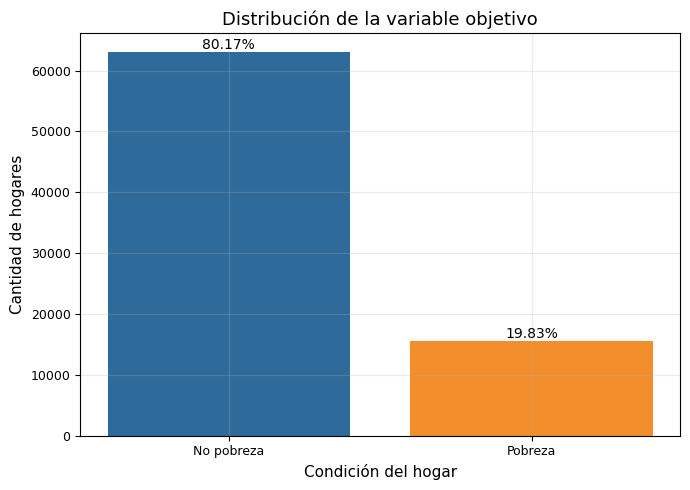

In [4]:
# ============================================================
# BLOQUE 4: Revisión general de la base y variable objetivo
# ============================================================

# Se crea una copia de la base para el análisis exploratorio
df_eda = df.copy()

# Se asegura que la variable objetivo esté en formato entero
df_eda["pobreza_ingresos"] = df_eda["pobreza_ingresos"].astype(int)

# Resumen general de la base
mostrar_titulo("Resumen general de la base")
print("Número de hogares:", df_eda.shape[0])
print("Número de variables:", df_eda.shape[1])
print("Valores perdidos:", df_eda.isna().sum().sum())

# Revisión de los tipos de datos presentes en la base
display(df_eda.dtypes.value_counts().to_frame("cantidad"))

# Tabla de frecuencia y porcentaje de la variable objetivo
tabla_objetivo = pd.DataFrame({
    "frecuencia": df_eda["pobreza_ingresos"].value_counts().sort_index(),
    "porcentaje": df_eda["pobreza_ingresos"].value_counts(normalize=True).sort_index() * 100
})

# Se renombran las categorías para facilitar la interpretación
tabla_objetivo.index = ["No pobreza", "Pobreza"]
tabla_objetivo["porcentaje"] = tabla_objetivo["porcentaje"].round(2)

# Se muestra la distribución de la variable objetivo
mostrar_titulo("Distribución de pobreza_ingresos")
display(tabla_objetivo)

# Gráfico de barras para visualizar la distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(7, 5))

barras = ax.bar(
    tabla_objetivo.index,
    tabla_objetivo["frecuencia"],
    color=[PALETA["azul"], PALETA["naranjo"]]
)

ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Condición del hogar")
ax.set_ylabel("Cantidad de hogares")

# Se agregan los porcentajes sobre cada barra
for barra, porcentaje in zip(barras, tabla_objetivo["porcentaje"]):
    ax.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height(),
        f"{porcentaje:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

La revisión permite confirmar el tamaño de la base, la ausencia o presencia de valores perdidos y la distribución de la variable objetivo. Esto es importante porque la proporción entre hogares pobres y no pobres influye en la evaluación posterior de los modelos.


En este bloque se comparan las variables numéricas según la condición de pobreza. Esto permite observar diferencias generales entre hogares pobres y no pobres antes de construir los modelos.



Resumen descriptivo de variables numéricas


,count,mean,std,min,25%,50%,75%,max
edad,"78,654.000",54.698,16.268,16.000,42.000,55.000,67.000,103.000
esc,"78,654.000",11.274,4.417,0.000,8.000,12.000,15.000,31.000
numper,"78,654.000",2.775,1.461,1.000,2.000,3.000,4.000,19.000
tasa_ocupados_hogar,"78,654.000",0.461,0.347,0.000,0.200,0.500,0.667,1.000
tasa_desocupados_hogar,"78,654.000",0.043,0.142,0.000,0.000,0.000,0.000,1.000
tasa_inactivos_hogar,"78,654.000",0.379,0.365,0.000,0.000,0.333,0.667,1.000



Medias de variables numéricas según pobreza


,No pobreza,Pobreza,Diferencia pobreza - no pobreza
edad,55.023,53.380,-1.643
esc,11.645,9.774,-1.871
numper,2.782,2.746,-0.036
tasa_ocupados_hogar,0.517,0.233,-0.284
tasa_desocupados_hogar,0.033,0.084,0.051
tasa_inactivos_hogar,0.345,0.517,0.172


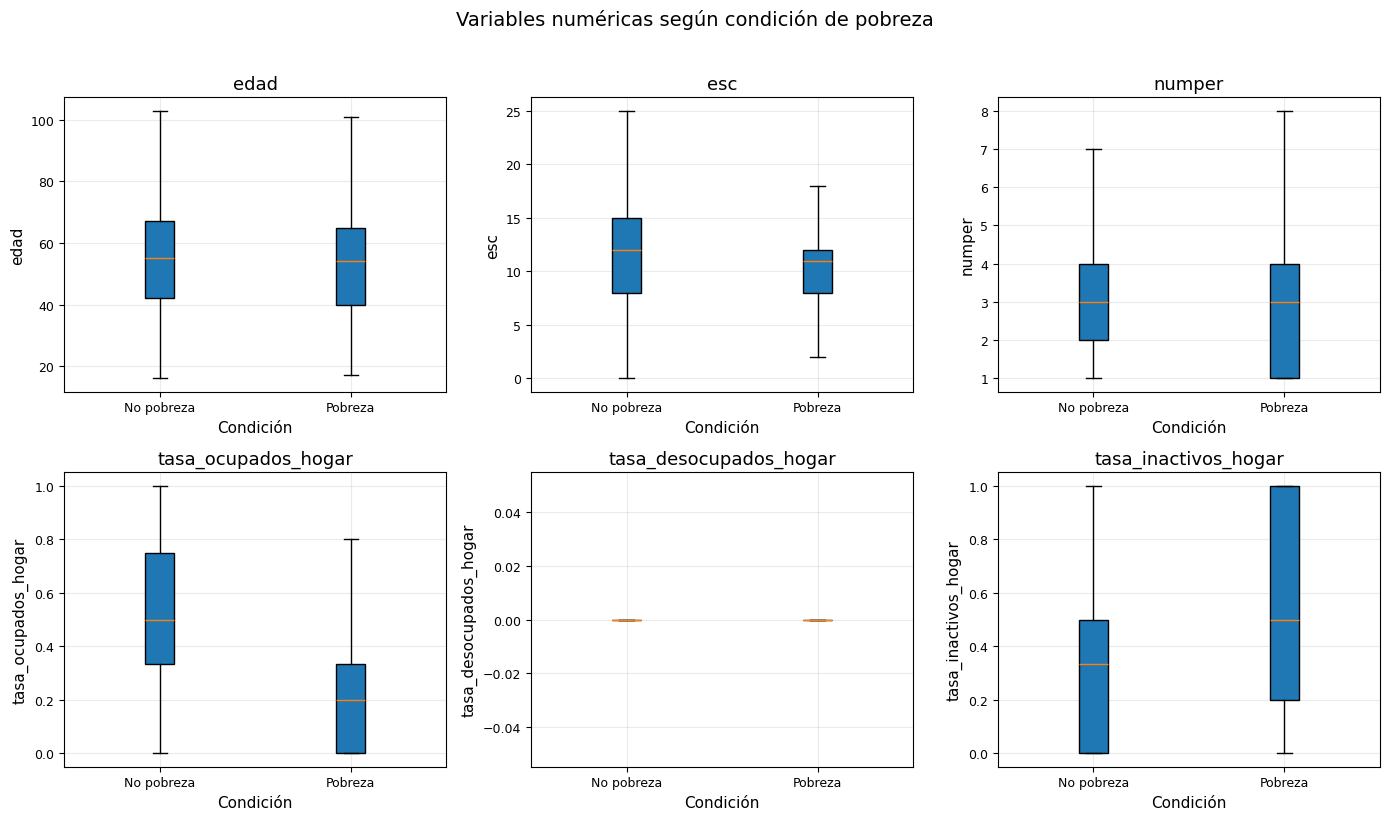

In [6]:
# ============================================================
# BLOQUE 5: EDA bivariado de variables numéricas
# ============================================================

# Resumen descriptivo general de las variables numéricas
mostrar_titulo("Resumen descriptivo de variables numéricas")
display(df_eda[variables_numericas_eda].describe().T.round(3))

# Cálculo de medias por grupo de pobreza
mostrar_titulo("Medias de variables numéricas según pobreza")

tabla_medias = df_eda.groupby("pobreza_ingresos")[variables_numericas_eda].mean().T
tabla_medias.columns = ["No pobreza", "Pobreza"]

# Diferencia entre hogares pobres y no pobres
tabla_medias["Diferencia pobreza - no pobreza"] = (
    tabla_medias["Pobreza"] - tabla_medias["No pobreza"]
)

display(tabla_medias.round(3))

# Boxplots para comparar la distribución de cada variable numérica según pobreza
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, var in zip(axes, variables_numericas_eda):
    datos_plot = [
        df_eda.loc[df_eda["pobreza_ingresos"] == 0, var],
        df_eda.loc[df_eda["pobreza_ingresos"] == 1, var]
    ]

    # Se ocultan valores extremos solo para mejorar la visualización del gráfico
    ax.boxplot(
        datos_plot,
        tick_labels=["No pobreza", "Pobreza"],
        showfliers=False,
        patch_artist=True
    )

    ax.set_title(var)
    ax.set_xlabel("Condición")
    ax.set_ylabel(var)

fig.suptitle("Variables numéricas según condición de pobreza", fontsize=14, y=1.02)
plt.show()

Las tablas y gráficos permiten identificar diferencias iniciales entre ambos grupos. Estas comparaciones son descriptivas y sirven como apoyo para entender qué variables podrían aportar información al modelo.


Se analizan variables categóricas seleccionadas, usando etiquetas más interpretables para facilitar la lectura de tablas y gráficos. El objetivo es comparar el porcentaje de pobreza entre distintas categorías de hogares.



EDA categórico: Laborales

Variable: activ_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
activ_label,,,,,
Desocupado,1445,1319,2764,47.720,3.510
Inactivo,19593,7810,27403,28.500,34.840
Ocupado,42021,6466,48487,13.340,61.650


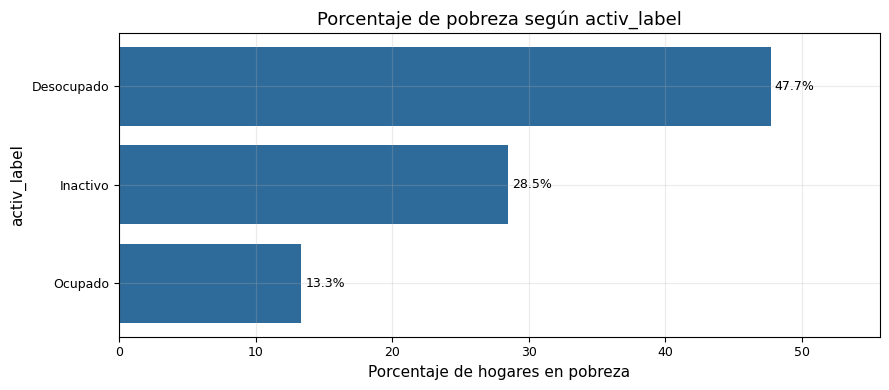


Variable: contrato_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
contrato_label,,,,,
No aplica,31583,12103,43686,27.700,55.540
No,3318,1153,4471,25.790,5.680
No sabe,52,7,59,11.860,0.080
Sí,28106,2332,30438,7.660,38.700


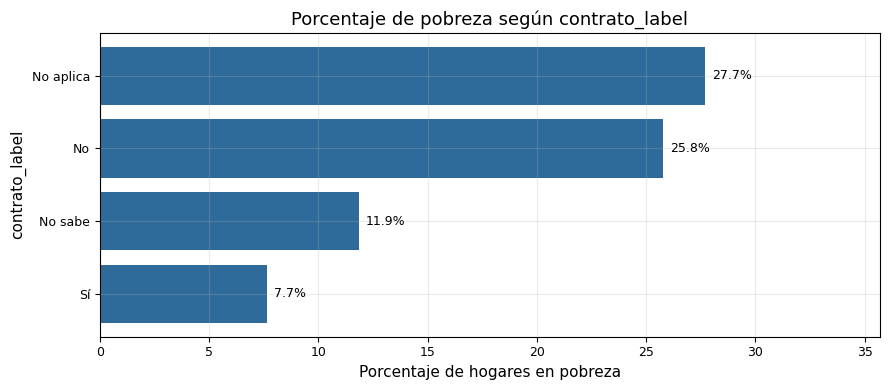


Variable: cotiza_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
cotiza_label,,,,,
No,29713,12066,41779,28.880,53.120
No sabe,155,57,212,26.890,0.270
Sí,33191,3472,36663,9.470,46.610


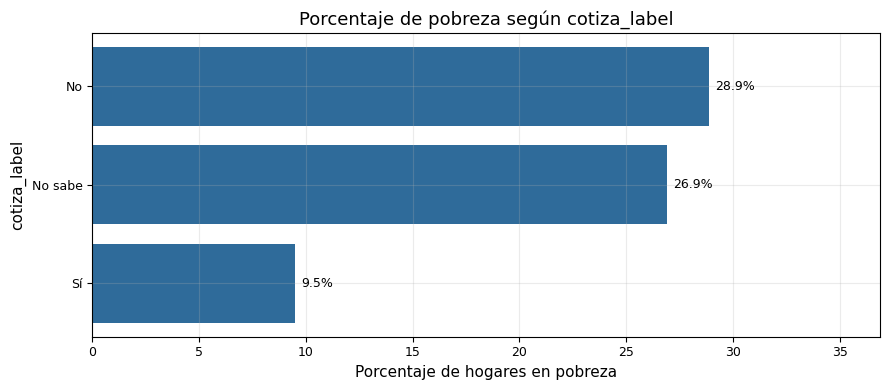


EDA categórico: Educación y hogar

Variable: grupo_escolaridad


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
grupo_escolaridad,,,,,
0 a 8 años,16145,5890,22035,26.730,28.020
9 a 12 años,23715,7098,30813,23.040,39.180
13 a 16 años,12876,2020,14896,13.560,18.940
17 años o más,10323,587,10910,5.380,13.870


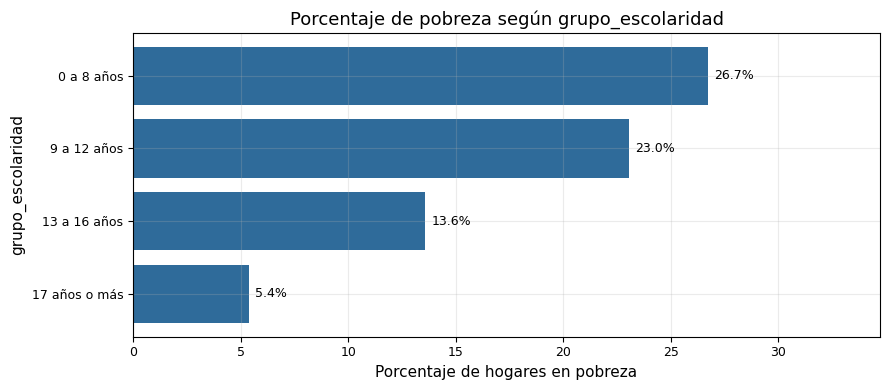


Variable: grupo_tamano_hogar


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
grupo_tamano_hogar,,,,,
1 persona,11771,4171,15942,26.160,20.270
4 a 5 personas,14780,3951,18731,21.090,23.810
6 o más personas,2700,709,3409,20.800,4.330
2 a 3 personas,33808,6764,40572,16.670,51.580


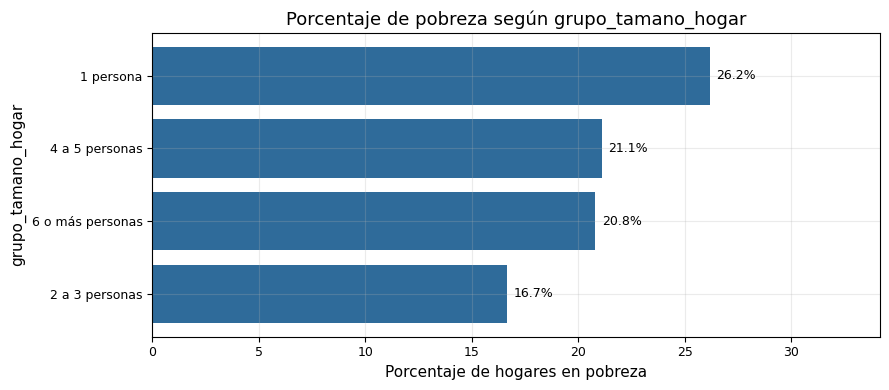


Variable: tipohogar_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
tipohogar_label,,,,,
Tipo 2,11492,4450,15942,27.910,20.270
Tipo 1,11771,4171,15942,26.160,20.270
Tipo 4,4091,902,4993,18.070,6.350
Tipo 3,29523,5253,34776,15.110,44.210
Tipo 6,1472,233,1705,13.670,2.170
Tipo 5,4710,586,5296,11.060,6.730


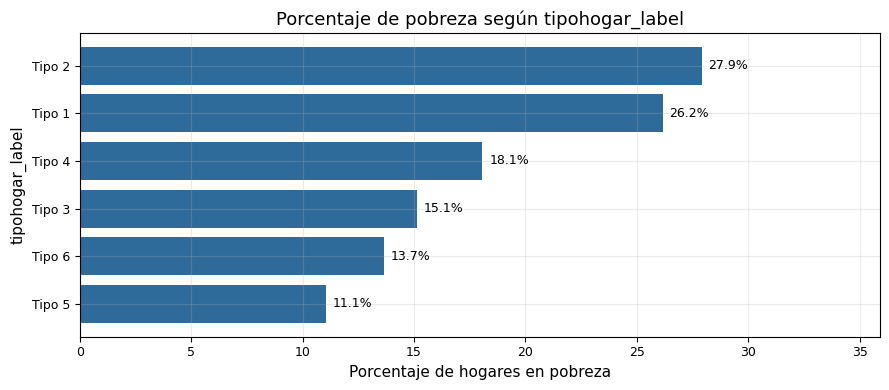


Variable: menores_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
menores_label,,,,,
Con menores,21802,7177,28979,24.770,36.840
Sin menores,41257,8418,49675,16.950,63.160


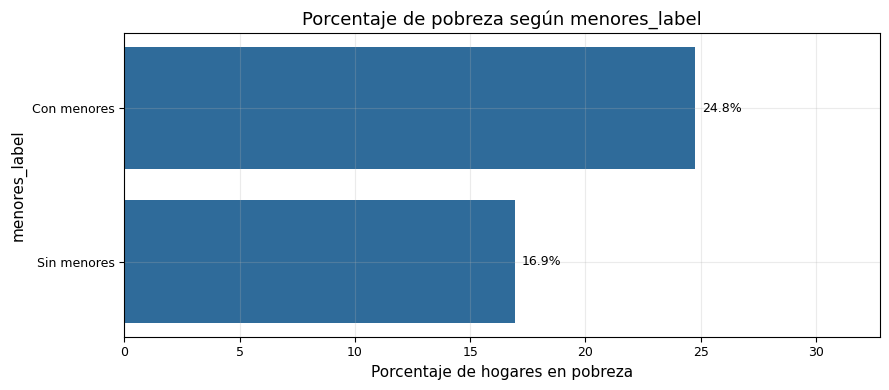


Variable: mayores_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
mayores_label,,,,,
Sin adultos mayores,33106,8940,42046,21.260,53.460
Con adultos mayores,29953,6655,36608,18.180,46.540


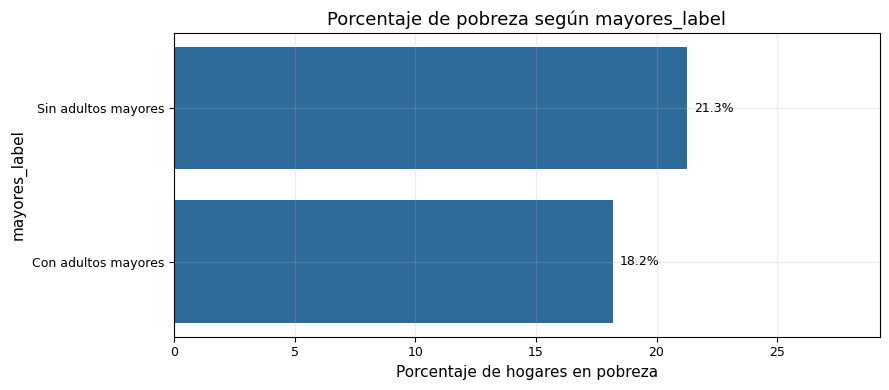


EDA categórico: Territorio y vivienda

Variable: area_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
area_label,,,,,
Rural,10595,3627,14222,25.500,18.080
Urbana,52464,11968,64432,18.570,81.920


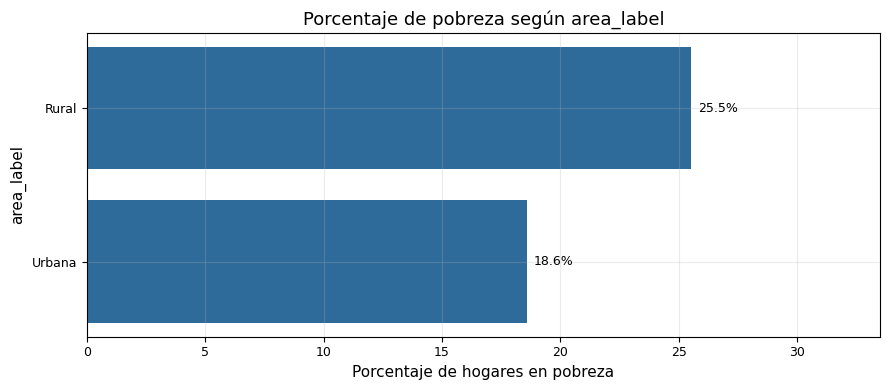


Variable: region_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
region_label,,,,,
La Araucanía,3783,1675,5458,30.690,6.940
Ñuble,2594,902,3496,25.800,4.440
Maule,4161,1417,5578,25.400,7.090
Los Ríos,2620,813,3433,23.680,4.360
Coquimbo,2818,820,3638,22.540,4.630
Arica y Parinacota,2225,570,2795,20.390,3.550
Biobío,6471,1653,8124,20.350,10.330
Atacama,2602,655,3257,20.110,4.140
Tarapacá,2484,609,3093,19.690,3.930


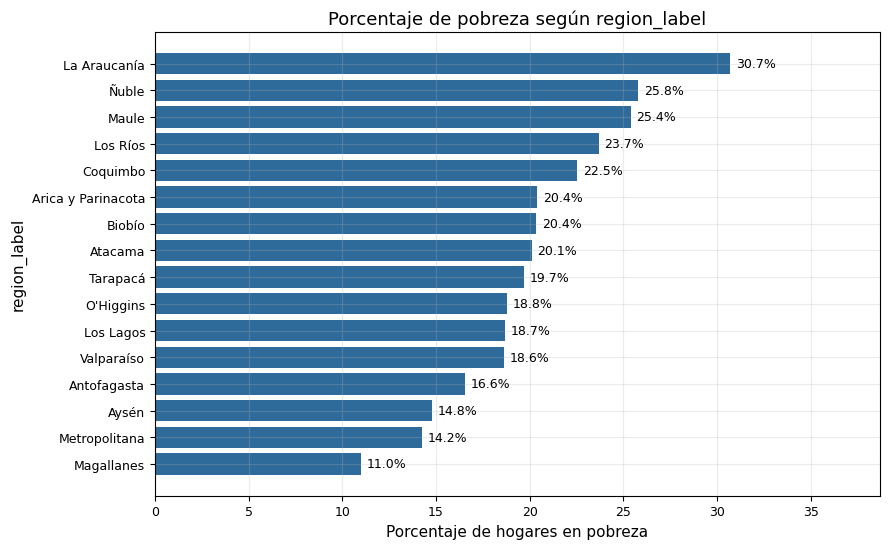


Variable: hacina_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
hacina_label,,,,,
Alto,166,172,338,50.890,0.430
Crítico,124,102,226,45.130,0.290
No sabe,12,9,21,42.860,0.030
Medio,1330,803,2133,37.650,2.710
Sin hacinamiento,61427,14509,75936,19.110,96.540


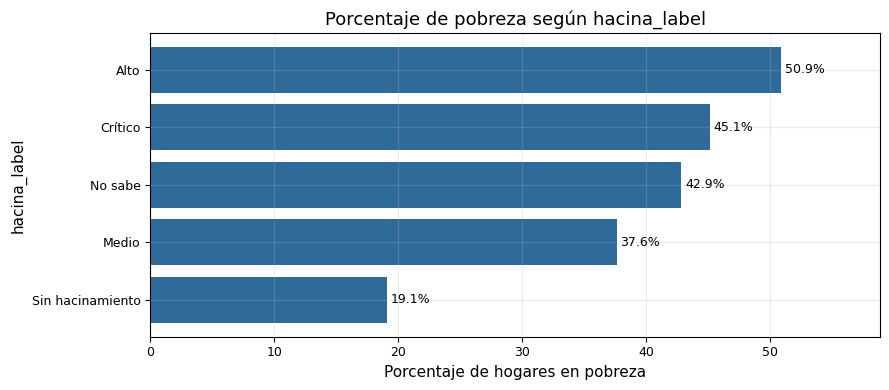


Variable: san_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
san_label,,,,,
Deficitario,3106,1671,4777,34.980,6.070
Aceptable,59953,13924,73877,18.850,93.930


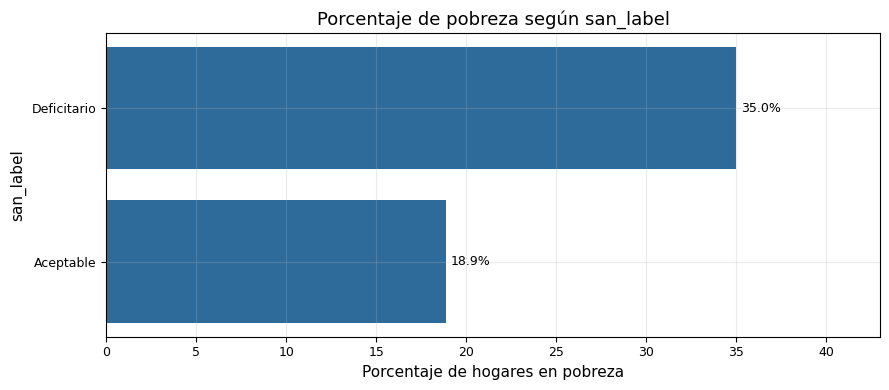


Variable: calidad_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
calidad_label,,,,,
Irrecuperable,166,134,300,44.670,0.380
Recuperable,5553,2715,8268,32.840,10.510
Aceptable,57340,12746,70086,18.190,89.110


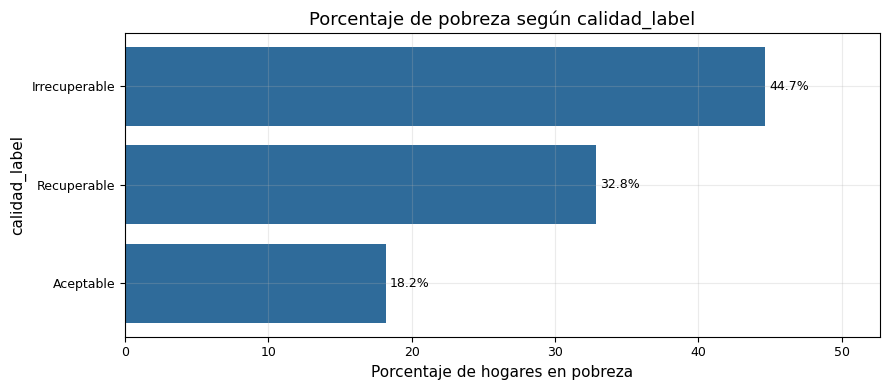


Variable: tenencia_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
tenencia_label,,,,,
Informal,11948,5028,16976,29.620,21.580
Formal,51111,10567,61678,17.130,78.420


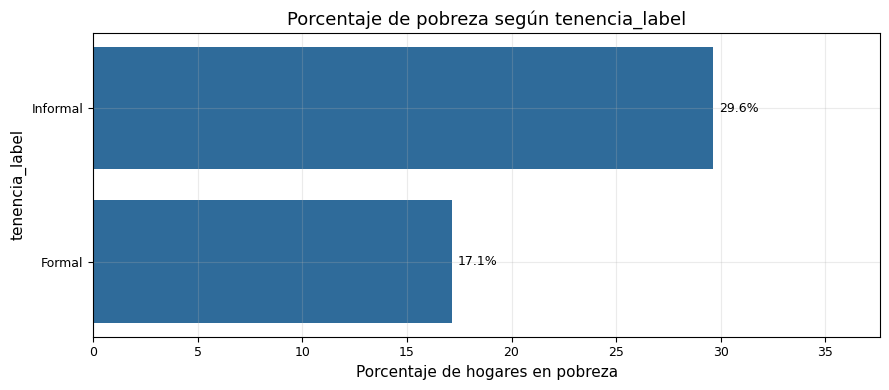


EDA categórico: Jefatura y vulnerabilidad

Variable: jefatura_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
jefatura_label,,,,,
Jefatura mujer,30917,9822,40739,24.110,51.800
Jefatura hombre,32142,5773,37915,15.230,48.200


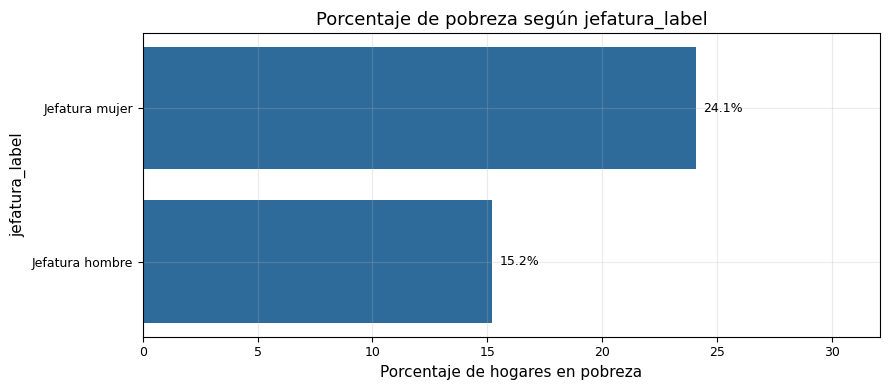


Variable: pueblos_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
pueblos_label,,,,,
Pertenece,7592,2557,10149,25.190,12.900
No pertenece,55467,13038,68505,19.030,87.100


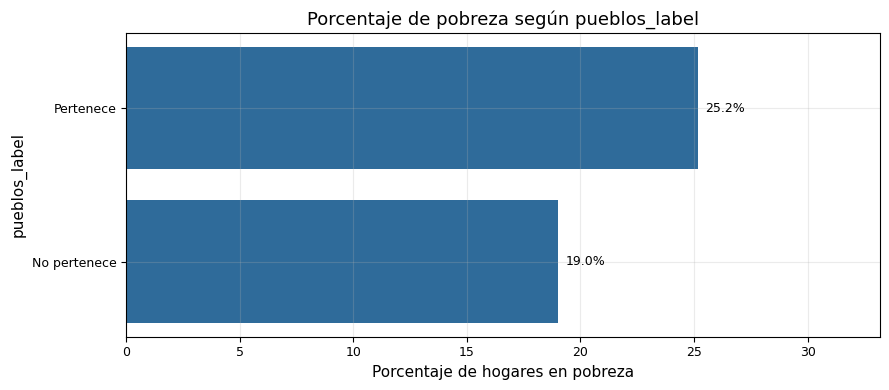


Variable: disc_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
disc_label,,,,,
No sabe,8,3,11,27.270,0.010
Con discapacidad,9087,3083,12170,25.330,15.470
Sin discapacidad,53964,12509,66473,18.820,84.510


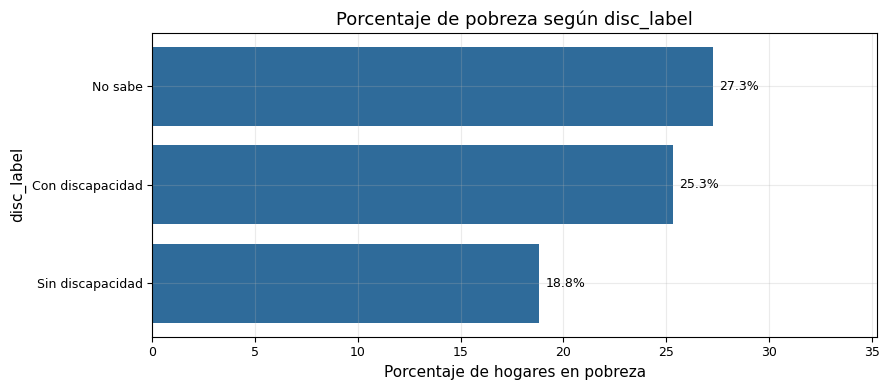


Variable: nacimiento_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
nacimiento_label,,,,,
Nacido fuera de Chile,3639,1386,5025,27.580,6.390
No sabe,296,84,380,22.110,0.480
Nacido en Chile,59124,14125,73249,19.280,93.130


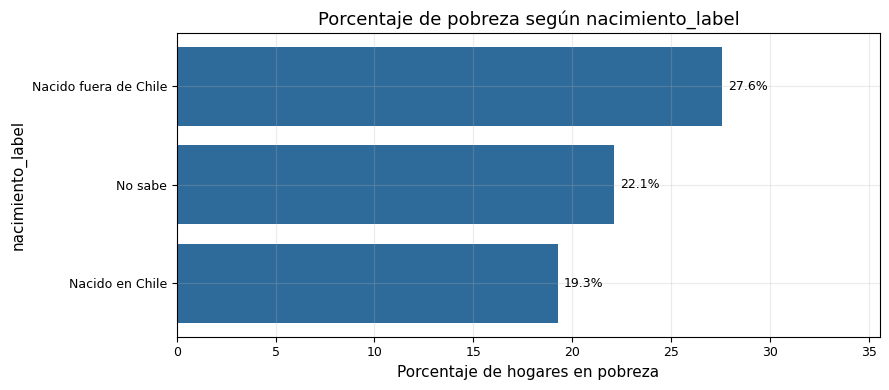

In [7]:
# ============================================================
# BLOQUE 6: EDA bivariado de variables categóricas seleccionadas
# ============================================================

# Se crea una copia de la base para trabajar variables categóricas con etiquetas
df_cat = df_eda.copy()

# Se reemplazan códigos numéricos por etiquetas más fáciles de interpretar
df_cat["activ_label"] = df_cat["activ"].map(map_activ)
df_cat["contrato_label"] = df_cat["contrato"].map(map_contrato)
df_cat["cotiza_label"] = df_cat["cotiza"].map(map_cotiza)
df_cat["jefatura_label"] = df_cat["jefatura_mujer"].map(map_jefatura)
df_cat["pueblos_label"] = df_cat["pueblos_indigenas"].map(map_pueblos)
df_cat["disc_label"] = df_cat["disc_wg"].map(map_disc)
df_cat["nacimiento_label"] = df_cat["nacido_fuera_chile"].map(map_nacimiento)
df_cat["menores_label"] = df_cat["men18c"].map(map_menores)
df_cat["mayores_label"] = df_cat["may60c"].map(map_mayores)
df_cat["area_label"] = df_cat["area"].map(map_area)
df_cat["region_label"] = df_cat["region"].map(map_region)
df_cat["hacina_label"] = df_cat["ind_hacina"].map(map_hacina)
df_cat["san_label"] = df_cat["ind_san"].map(map_san)
df_cat["calidad_label"] = df_cat["ind_cal_glob"].map(map_calidad)
df_cat["tenencia_label"] = df_cat["ten_viv_f"].map(map_tenencia)
df_cat["estado_viv_label"] = df_cat["ind_estado"].map(map_estado)

# Se etiqueta el tipo de hogar de forma simple
df_cat["tipohogar_label"] = df_cat["tipohogar"].apply(lambda x: f"Tipo {int(x)}")

# Se agrupa la escolaridad en rangos para facilitar el análisis
df_cat["grupo_escolaridad"] = pd.cut(
    df_cat["esc"],
    bins=[-1, 8, 12, 16, 40],
    labels=["0 a 8 años", "9 a 12 años", "13 a 16 años", "17 años o más"]
)

# Se agrupa el tamaño del hogar según cantidad de personas
df_cat["grupo_tamano_hogar"] = pd.cut(
    df_cat["numper"],
    bins=[0, 1, 3, 5, 30],
    labels=["1 persona", "2 a 3 personas", "4 a 5 personas", "6 o más personas"]
)

# Se organizan las variables categóricas por grupos temáticos
grupos_eda_categoricas = {
    "Laborales": ["activ_label", "contrato_label", "cotiza_label"],
    "Educación y hogar": [
        "grupo_escolaridad", "grupo_tamano_hogar",
        "tipohogar_label", "menores_label", "mayores_label"
    ],
    "Territorio y vivienda": [
        "area_label", "region_label", "hacina_label",
        "san_label", "calidad_label", "tenencia_label"
    ],
    "Jefatura y vulnerabilidad": [
        "jefatura_label", "pueblos_label", "disc_label", "nacimiento_label"
    ]
}

# Para cada grupo se generan tablas y gráficos de porcentaje de pobreza
for nombre_grupo, variables in grupos_eda_categoricas.items():
    mostrar_titulo(f"EDA categórico: {nombre_grupo}")

    for var in variables:
        print(f"\nVariable: {var}")

        # Tabla de frecuencia y porcentaje de pobreza por categoría
        tabla = tabla_pobreza_categoria(df_cat, var)
        display(tabla)

        # Gráfico del porcentaje de pobreza por categoría
        graficar_barras_porcentaje(
            tabla,
            f"Porcentaje de pobreza según {var}",
            xlabel=var
        )

Este análisis permite observar qué categorías presentan mayores porcentajes de pobreza. Los resultados son descriptivos y ayudan a identificar patrones iniciales antes del modelamiento.



Matriz de correlación


,pobreza_ingresos,edad,esc,numper,n_ocupados,n_desocupados,n_inactivos,tasa_ocupados_hogar,tasa_desocupados_hogar,tasa_inactivos_hogar
pobreza_ingresos,1.000,-0.040,-0.169,-0.010,-0.297,0.131,0.126,-0.326,0.143,0.188
edad,-0.040,1.000,-0.479,-0.190,-0.307,-0.044,0.361,-0.323,-0.046,0.557
esc,-0.169,-0.479,1.000,0.051,0.204,0.005,-0.244,0.254,0.013,-0.340
numper,-0.010,-0.190,0.051,1.000,0.537,0.189,0.397,-0.132,0.018,-0.150
n_ocupados,-0.297,-0.307,0.204,0.537,1.000,-0.070,-0.311,0.650,-0.144,-0.643
n_desocupados,0.131,-0.044,0.005,0.189,-0.070,1.000,-0.068,-0.183,0.854,-0.165
n_inactivos,0.126,0.361,-0.244,0.397,-0.311,-0.068,1.000,-0.640,-0.132,0.732
tasa_ocupados_hogar,-0.326,-0.323,0.254,-0.132,0.650,-0.183,-0.640,1.000,-0.196,-0.793
tasa_desocupados_hogar,0.143,-0.046,0.013,0.018,-0.144,0.854,-0.132,-0.196,1.000,-0.177
tasa_inactivos_hogar,0.188,0.557,-0.340,-0.150,-0.643,-0.165,0.732,-0.793,-0.177,1.000



Correlación con pobreza_ingresos


,correlacion
tasa_ocupados_hogar,-0.326
n_ocupados,-0.297
tasa_inactivos_hogar,0.188
esc,-0.169
tasa_desocupados_hogar,0.143
n_desocupados,0.131
n_inactivos,0.126
edad,-0.040
numper,-0.010


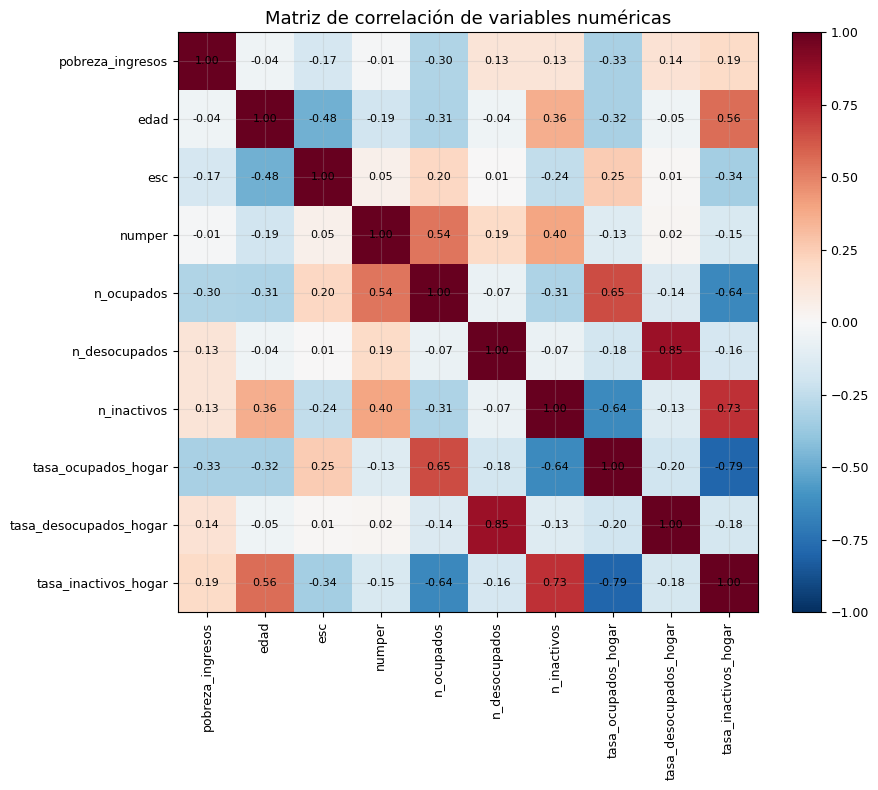


Pares con correlación absoluta mayor o igual a 0.70


,variable_1,variable_2,correlacion
0,n_desocupados,tasa_desocupados_hogar,0.854
1,n_inactivos,tasa_inactivos_hogar,0.732
2,tasa_ocupados_hogar,tasa_inactivos_hogar,-0.793


In [8]:
# ============================================================
# BLOQUE 7: Correlaciones entre variables numéricas
# ============================================================

# Se calcula la matriz de correlación entre las variables numéricas
corr = df_eda[variables_numericas_modelo].corr()

# Se muestra la matriz completa
mostrar_titulo("Matriz de correlación")
display(corr.round(3))

# Se extraen las correlaciones con la variable objetivo
corr_objetivo = corr["pobreza_ingresos"].drop("pobreza_ingresos").sort_values(
    key=lambda x: abs(x), ascending=False
)

# Se muestran las variables numéricas más relacionadas con pobreza_ingresos
mostrar_titulo("Correlación con pobreza_ingresos")
display(corr_objetivo.round(3).to_frame("correlacion"))

# Gráfico tipo mapa de calor para visualizar la matriz de correlación
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
ax.set_title("Matriz de correlación de variables numéricas")

# Se agregan los valores de correlación dentro de cada celda
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

# Se identifican pares de variables con correlación alta
pares_correlacion = []

for i in range(len(variables_numericas_modelo)):
    for j in range(i + 1, len(variables_numericas_modelo)):
        var1 = variables_numericas_modelo[i]
        var2 = variables_numericas_modelo[j]
        valor = corr.loc[var1, var2]

        # Se guarda el par si la correlación absoluta es mayor o igual a 0.70
        if abs(valor) >= 0.70:
            pares_correlacion.append({
                "variable_1": var1,
                "variable_2": var2,
                "correlacion": round(valor, 3)
            })

# Se muestran los pares con correlación alta, si existen
mostrar_titulo("Pares con correlación absoluta mayor o igual a 0.70")

pares_correlacion = pd.DataFrame(pares_correlacion)

if pares_correlacion.empty:
    print("No se encontraron pares con correlación alta.")
else:
    display(pares_correlacion)

La matriz de correlación permite revisar asociaciones entre variables numéricas. Además, la identificación de pares con correlación alta ayuda a detectar posibles variables que entregan información similar.


se evalúa la asociación entre las variables categóricas y la pobreza por ingresos, usando la prueba chi-cuadrado y la V de Cramer como medida de fuerza de asociación.



Asociación entre variables categóricas y pobreza_ingresos


,variable,n_categorias,chi2,gl,valor_p,v_cramer
0,contrato,4,"4,641.646",3,0.000,0.243
1,cotiza,3,"4,634.948",2,0.000,0.243
2,activ,3,"3,935.104",2,0.000,0.224
3,tipohogar,6,"1,852.511",5,0.000,0.153
4,ind_estado,3,"1,675.360",2,0.000,0.146
5,ecivil,8,"1,447.002",7,0.000,0.136
6,ten_viv_f,2,"1,304.735",1,0.000,0.129
7,ind_cal_glob,3,"1,115.570",2,0.000,0.119
8,region,16,"1,103.013",15,0.000,0.118
9,jefatura_mujer,2,974.362,1,0.000,0.111


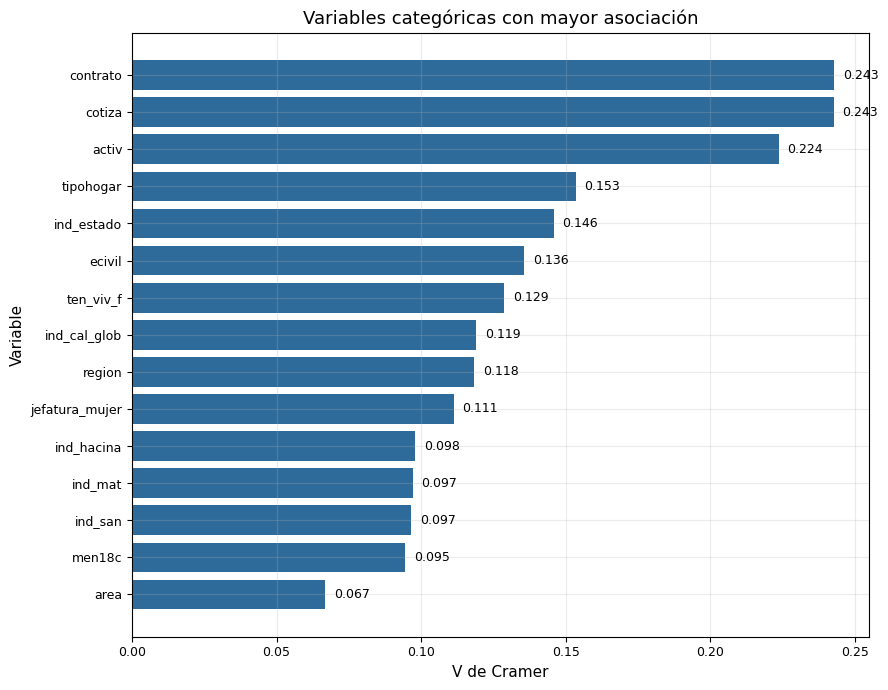


Tablas de pobreza para las variables categóricas más asociadas

Variable: contrato


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
contrato,,,,,
2.000,31583,12103,43686,27.700,55.540
0.000,3318,1153,4471,25.790,5.680
3.000,52,7,59,11.860,0.080
1.000,28106,2332,30438,7.660,38.700



Variable: cotiza


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
cotiza,,,,,
0.000,29713,12066,41779,28.880,53.120
2.000,155,57,212,26.890,0.270
1.000,33191,3472,36663,9.470,46.610



Variable: activ


...

,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
ecivil,,,,,
5.000,3976,1522,5498,27.680,6.990
8.000,13439,4800,18239,26.320,23.190
7.000,6429,1925,8354,23.040,10.620
6.000,3651,1035,4686,22.090,5.960
2.000,12013,2555,14568,17.540,18.520
4.000,116,20,136,14.710,0.170
1.000,23123,3695,26818,13.780,34.100
3.000,312,43,355,12.110,0.450



Variable: ten_viv_f


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
ten_viv_f,,,,,
2,11948,5028,16976,29.620,21.580
1,51111,10567,61678,17.130,78.420



Variable: ind_cal_glob


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
ind_cal_glob,,,,,
3,166,134,300,44.670,0.380
2,5553,2715,8268,32.840,10.510
1,57340,12746,70086,18.190,89.110


In [9]:
# ============================================================
# BLOQUE 8: Asociación bivariada de variables categóricas
# ============================================================

# Lista para almacenar los resultados de asociación por variable
resultados_categoricas = []

# Se calcula chi-cuadrado y V de Cramer para cada variable categórica
for var in variables_categoricas:
    tabla = pd.crosstab(df_eda[var], df_eda["pobreza_ingresos"])
    v_cramer, chi2, p_valor, gl = cramer_v(tabla)

    resultados_categoricas.append({
        "variable": var,
        "n_categorias": df_eda[var].nunique(),
        "chi2": chi2,
        "gl": gl,
        "valor_p": p_valor,
        "v_cramer": v_cramer
    })

# Se ordenan las variables según la fuerza de asociación
resultados_categoricas = (
    pd.DataFrame(resultados_categoricas)
    .sort_values("v_cramer", ascending=False)
    .reset_index(drop=True)
)

# Tabla resumen de asociación entre variables categóricas y pobreza
mostrar_titulo("Asociación entre variables categóricas y pobreza_ingresos")
display(resultados_categoricas.round({"chi2": 3, "v_cramer": 3}))

# Gráfico con las 15 variables categóricas más asociadas a la pobreza
fig, ax = plt.subplots(figsize=(9, 7))

top_v = resultados_categoricas.head(15).iloc[::-1]

ax.barh(top_v["variable"], top_v["v_cramer"], color=PALETA["azul"])
ax.set_title("Variables categóricas con mayor asociación")
ax.set_xlabel("V de Cramer")
ax.set_ylabel("Variable")

# Se agregan los valores de V de Cramer al lado de cada barra
for i, v in enumerate(top_v["v_cramer"]):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9)

plt.show()

# Se muestran tablas descriptivas para las variables con mayor asociación
mostrar_titulo("Tablas de pobreza para las variables categóricas más asociadas")

for var in resultados_categoricas.head(8)["variable"]:
    print(f"\nVariable: {var}")
    display(tabla_pobreza_categoria(df_eda, var))

La V de Cramer permite ordenar las variables categóricas según su nivel de asociación con la pobreza. Estos resultados son exploratorios y ayudan a reconocer qué variables podrían ser relevantes para el modelo.


## 3. Preparación para modelamiento

En este bloque se separa la variable objetivo de las variables predictoras y se divide la base en entrenamiento y prueba. La partición se realiza de forma estratificada para mantener una proporción similar de hogares pobres y no pobres en ambos conjuntos.


In [10]:
# ============================================================
# BLOQUE 9: Preparación de datos para modelamiento
# ============================================================

# Se define la variable objetivo
variable_objetivo = "pobreza_ingresos"

# Vector objetivo
y = df_eda[variable_objetivo].astype(int)

# Matriz de variables predictoras para la regresión logística
X = df_eda[variables_predictoras_logistica].copy()

# División en entrenamiento y prueba, manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Preprocesamiento para regresión logística
preprocesamiento_logistica = ColumnTransformer(
    transformers=[
        # Las variables numéricas se estandarizan
        ("numericas", StandardScaler(), variables_numericas_logistica),

        # Las variables categóricas se transforman con One Hot Encoding
        ("categoricas", OneHotEncoder(handle_unknown="ignore"), variables_categoricas_logistica)
    ]
)

# Resumen de la preparación de datos
mostrar_titulo("Preparación de datos")
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)
print("Variables excluidas por redundancia laboral: n_ocupados, n_desocupados, n_inactivos")

# Comparación de la distribución de clases en train y test
tabla_distribucion = pd.DataFrame({
    "Train (%)": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "Test (%)": (y_test.value_counts(normalize=True).sort_index() * 100).round(2)
})

tabla_distribucion.index = ["No pobreza", "Pobreza"]

display(tabla_distribucion)


Preparación de datos
Dimensión de X: (78654, 25)
Dimensión de y: (78654,)
Entrenamiento: (55057, 25)
Prueba: (23597, 25)
Variables excluidas por redundancia laboral: n_ocupados, n_desocupados, n_inactivos


,Train (%),Test (%)
No pobreza,80.170,80.170
Pobreza,19.830,19.830


La base queda dividida en conjuntos de entrenamiento y prueba. La distribución similar de la variable objetivo confirma que la partición estratificada funcionó correctamente.


## 4. Regresión logística

Se ajustan dos modelos de regresión logística: uno base y otro con ponderación de clases. El modelo balanceado se incluye para considerar el desbalance existente entre hogares pobres y no pobres.


In [11]:
# ============================================================
# BLOQUE 10: Ajuste de regresiones logísticas
# ============================================================

# Modelo logístico base con preprocesamiento incluido
modelo_logistico_base = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento_logistica),
        ("modelo", LogisticRegression(max_iter=1000, random_state=SEED))
    ]
)

# Modelo logístico con ajuste por desbalance de clases
modelo_logistico_balanceado = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento_logistica),
        ("modelo", LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced"))
    ]
)

# Ajuste de ambos modelos usando los datos de entrenamiento
modelo_logistico_base.fit(X_train, y_train)
modelo_logistico_balanceado.fit(X_train, y_train)

# Predicciones del modelo base
y_pred_base = modelo_logistico_base.predict(X_test)
y_prob_base = modelo_logistico_base.predict_proba(X_test)[:, 1]

# Predicciones del modelo balanceado
y_pred_balanceado = modelo_logistico_balanceado.predict(X_test)
y_prob_balanceado = modelo_logistico_balanceado.predict_proba(X_test)[:, 1]

print("Modelos ajustados correctamente.")

Modelos ajustados correctamente.


Los modelos fueron entrenados correctamente. Para ambos casos se obtienen predicciones de clase y probabilidades, las cuales serán utilizadas posteriormente para evaluar y comparar su desempeño.


En este bloque se comparan ambos modelos usando distintas métricas de clasificación. Además, se revisan las matrices de confusión y las curvas ROC y Precision-Recall para evaluar mejor el desempeño.



Comparación de métricas


,modelo,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Regresión logística base,0.837,0.646,0.395,0.490,0.849,0.588
1,Regresión logística balanceada,0.760,0.440,0.780,0.563,0.850,0.583



Matriz de confusión - Regresión logística base


,Predicho: No pobreza,Predicho: Pobreza
Real: No pobreza,17903,1015
Real: Pobreza,2829,1850


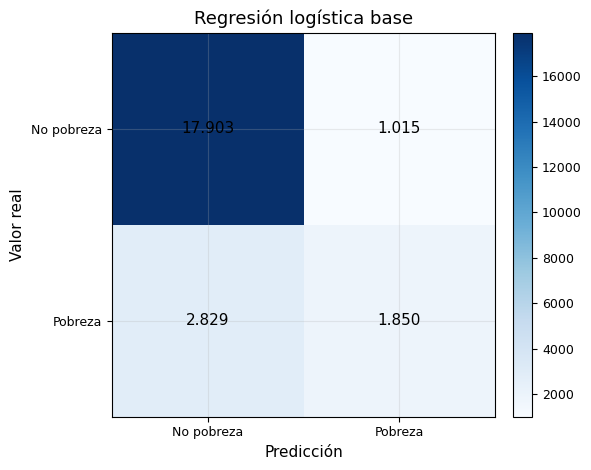


Matriz de confusión - Regresión logística balanceada


,Predicho: No pobreza,Predicho: Pobreza
Real: No pobreza,14276,4642
Real: Pobreza,1031,3648


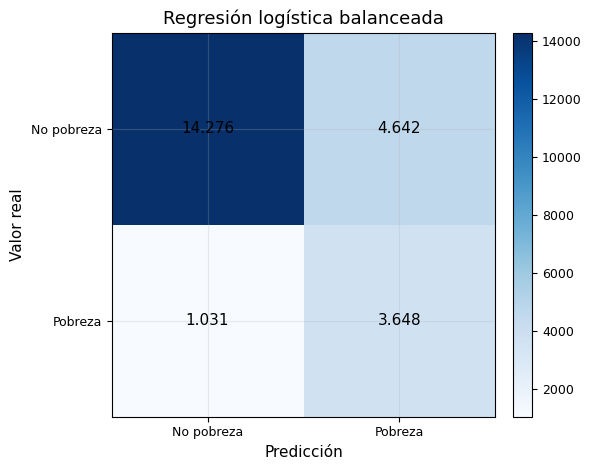


Reporte de clasificación - modelo base
              precision    recall  f1-score   support

  No pobreza       0.86      0.95      0.90     18918
     Pobreza       0.65      0.40      0.49      4679

    accuracy                           0.84     23597
   macro avg       0.75      0.67      0.70     23597
weighted avg       0.82      0.84      0.82     23597


Reporte de clasificación - modelo balanceado
              precision    recall  f1-score   support

  No pobreza       0.93      0.75      0.83     18918
     Pobreza       0.44      0.78      0.56      4679

    accuracy                           0.76     23597
   macro avg       0.69      0.77      0.70     23597
weighted avg       0.83      0.76      0.78     23597



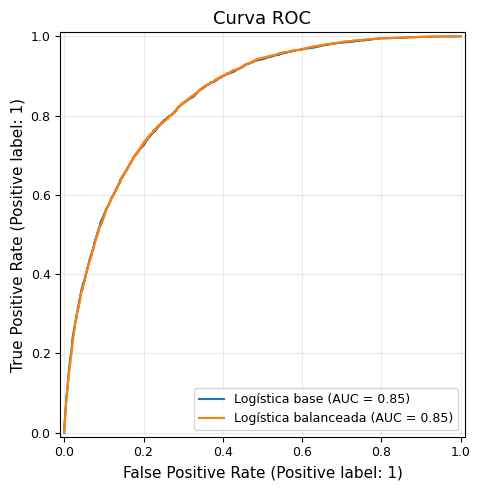

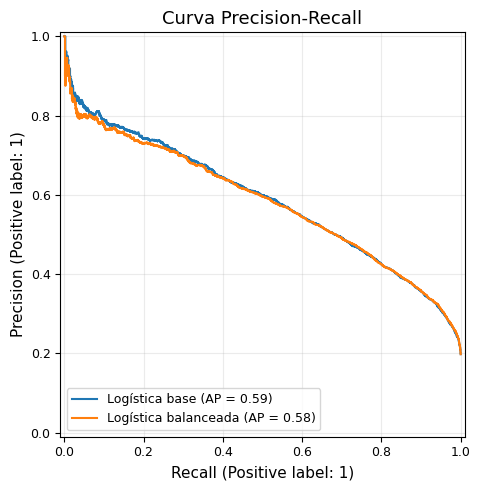

In [12]:
# ============================================================
# BLOQUE 11: Evaluación de regresiones logísticas
# ============================================================

# Se calculan las métricas principales para ambos modelos
metricas_base = evaluar_modelo("Regresión logística base", y_test, y_pred_base, y_prob_base)
metricas_balanceado = evaluar_modelo("Regresión logística balanceada", y_test, y_pred_balanceado, y_prob_balanceado)

# Se construye una tabla comparativa de métricas
tabla_metricas = pd.DataFrame([metricas_base, metricas_balanceado])

# Se redondean los resultados para facilitar la lectura
for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]:
    tabla_metricas[col] = tabla_metricas[col].round(3)

# Se muestra la comparación de métricas
mostrar_titulo("Comparación de métricas")
display(tabla_metricas)

# Matrices de confusión para ambos modelos
matriz_base = mostrar_matriz_confusion("Regresión logística base", y_test, y_pred_base)
matriz_balanceado = mostrar_matriz_confusion("Regresión logística balanceada", y_test, y_pred_balanceado)

# Reporte detallado de clasificación del modelo base
mostrar_titulo("Reporte de clasificación - modelo base")
print(classification_report(
    y_test,
    y_pred_base,
    target_names=["No pobreza", "Pobreza"],
    zero_division=0
))

# Reporte detallado de clasificación del modelo balanceado
mostrar_titulo("Reporte de clasificación - modelo balanceado")
print(classification_report(
    y_test,
    y_pred_balanceado,
    target_names=["No pobreza", "Pobreza"],
    zero_division=0
))

# Curva ROC para comparar la capacidad de discriminación de ambos modelos
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, y_prob_base, name="Logística base", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_balanceado, name="Logística balanceada", ax=ax)

ax.set_title("Curva ROC")
ax.grid(alpha=0.25)
plt.show()

# Curva Precision-Recall, útil cuando existe desbalance entre clases
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(y_test, y_prob_base, name="Logística base", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_prob_balanceado, name="Logística balanceada", ax=ax)

ax.set_title("Curva Precision-Recall")
ax.grid(alpha=0.25)
plt.show()

La comparación permite observar diferencias entre el modelo base y el modelo balanceado. En este caso, no solo se considera el accuracy, ya que también interesa evaluar métricas como recall, F1-score y PR-AUC por el desbalance de la variable objetivo.


En este bloque se ajusta una regresión logística balanceada pensada para interpretación. Se usa `drop="first"` en las variables categóricas para definir categorías de referencia y poder interpretar los coeficientes mediante odds ratios.



Métricas del modelo final


,modelo,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Regresión logística balanceada interpretativa,0.759,0.440,0.779,0.562,0.849,0.583



Matriz de confusión - Regresión logística balanceada interpretativa


,Predicho: No pobreza,Predicho: Pobreza
Real: No pobreza,14275,4643
Real: Pobreza,1034,3645


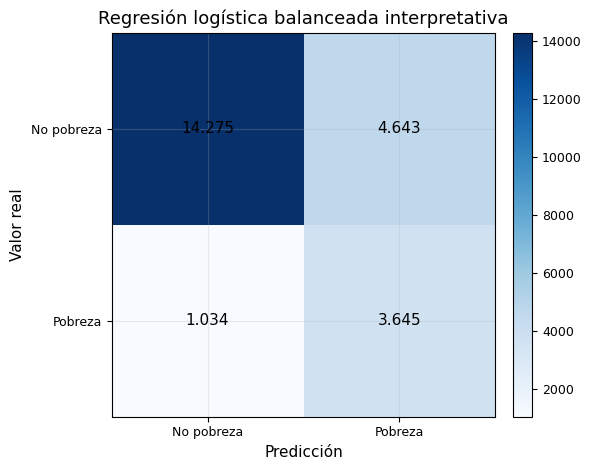


Categorías de referencia


,variable,categoria_referencia
0,jefatura_mujer,0.000
1,ecivil,1.000
2,activ,1.000
3,contrato,0.000
4,cotiza,0.000
5,disc_wg,0.000
6,pueblos_indigenas,0.000
7,nacido_fuera_chile,0.000
8,tipohogar,1.000
9,men18c,0.000



Coeficientes y odds ratios más relevantes


,variable_transformada,variable_original,coeficiente,odds_ratio,coef_abs
29,tipohogar_5,tipohogar,-1.659,0.190,1.659
3,tasa_ocupados_hogar,tasa_ocupados_hogar,-1.313,0.269,1.313
27,tipohogar_3,tipohogar,-1.215,0.297,1.215
15,activ_3.0,activ,-1.212,0.297,1.212
14,activ_2.0,activ,-1.141,0.320,1.141
16,contrato_1.0,contrato,-1.081,0.339,1.081
28,tipohogar_4,tipohogar,-1.045,0.352,1.045
30,tipohogar_6,tipohogar,-0.926,0.396,0.926
51,ind_hacina_4,ind_hacina,0.727,2.070,0.727
40,region_9,region,0.691,1.995,0.691



Variables/categorías asociadas a mayor probabilidad estimada de pobreza


,variable_transformada,variable_original,coeficiente,odds_ratio
51,ind_hacina_4,ind_hacina,0.727,2.070
40,region_9,region,0.691,1.995
50,ind_hacina_3,ind_hacina,0.621,1.861
24,nacido_fuera_chile_1,nacido_fuera_chile,0.615,1.850
47,region_16,region,0.571,1.771
38,region_7,region,0.522,1.685
58,ind_estado_3,ind_estado,0.520,1.682
45,region_14,region,0.449,1.567
49,ind_hacina_2,ind_hacina,0.444,1.558
61,ten_viv_f_2,ten_viv_f,0.429,1.537



Variables/categorías asociadas a menor probabilidad estimada de pobreza


,variable_transformada,variable_original,coeficiente,odds_ratio
29,tipohogar_5,tipohogar,-1.659,0.190
3,tasa_ocupados_hogar,tasa_ocupados_hogar,-1.313,0.269
27,tipohogar_3,tipohogar,-1.215,0.297
15,activ_3.0,activ,-1.212,0.297
14,activ_2.0,activ,-1.141,0.320
16,contrato_1.0,contrato,-1.081,0.339
28,tipohogar_4,tipohogar,-1.045,0.352
30,tipohogar_6,tipohogar,-0.926,0.396
0,edad,edad,-0.571,0.565
19,cotiza_1.0,cotiza,-0.562,0.570


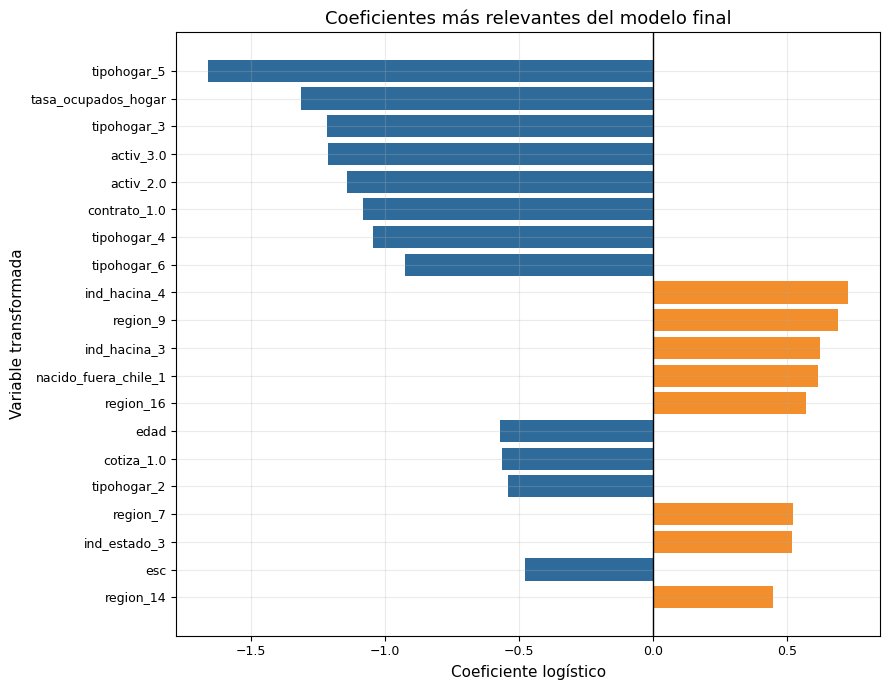

In [13]:
# ============================================================
# BLOQUE 12: Regresión logística interpretativa y odds ratios
# ============================================================

# Preprocesamiento para el modelo interpretativo
preprocesamiento_interpretacion = ColumnTransformer(
    transformers=[
        # Las variables numéricas se estandarizan
        ("numericas", StandardScaler(), variables_numericas_logistica),

        # Se elimina la primera categoría para usarla como referencia
        ("categoricas", OneHotEncoder(handle_unknown="ignore", drop="first"), variables_categoricas_logistica)
    ]
)

# Pipeline del modelo logístico balanceado para interpretación
modelo_logistico_interpretacion = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento_interpretacion),
        ("modelo", LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced"))
    ]
)

# Ajuste del modelo con los datos de entrenamiento
modelo_logistico_interpretacion.fit(X_train, y_train)

# Predicciones de clase y probabilidad
y_pred_interpretacion = modelo_logistico_interpretacion.predict(X_test)
y_prob_interpretacion = modelo_logistico_interpretacion.predict_proba(X_test)[:, 1]

# Evaluación del modelo interpretativo
metricas_interpretacion = evaluar_modelo(
    "Regresión logística balanceada interpretativa",
    y_test,
    y_pred_interpretacion,
    y_prob_interpretacion
)

# Tabla con métricas principales
tabla_metricas_interpretacion = pd.DataFrame([metricas_interpretacion])

for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]:
    tabla_metricas_interpretacion[col] = tabla_metricas_interpretacion[col].round(3)

mostrar_titulo("Métricas del modelo final")
display(tabla_metricas_interpretacion)

# Matriz de confusión del modelo final
tabla_matriz_interpretacion = mostrar_matriz_confusion(
    "Regresión logística balanceada interpretativa",
    y_test,
    y_pred_interpretacion
)

# Se extraen elementos del pipeline para obtener coeficientes y nombres de variables
preprocesador_interpretacion = modelo_logistico_interpretacion.named_steps["preprocesamiento"]
encoder_interpretacion = preprocesador_interpretacion.named_transformers_["categoricas"]
modelo_final_interpretacion = modelo_logistico_interpretacion.named_steps["modelo"]

# Tabla con las categorías de referencia de cada variable categórica
tabla_referencias = pd.DataFrame({
    "variable": variables_categoricas_logistica,
    "categoria_referencia": [categorias[0] for categorias in encoder_interpretacion.categories_]
})

mostrar_titulo("Categorías de referencia")
display(tabla_referencias)

# Nombres de variables transformadas
nombres_numericas = variables_numericas_logistica
nombres_categoricas = encoder_interpretacion.get_feature_names_out(variables_categoricas_logistica)
nombres_variables_transformadas = list(nombres_numericas) + list(nombres_categoricas)

# Coeficientes del modelo
coeficientes = modelo_final_interpretacion.coef_[0]

# Tabla inicial de coeficientes
tabla_or = pd.DataFrame({
    "variable_transformada": nombres_variables_transformadas,
    "coeficiente": coeficientes
})

# Función para identificar la variable original asociada a cada variable transformada
def identificar_variable_original(nombre):
    if nombre in variables_numericas_logistica:
        return nombre

    for var in variables_categoricas_logistica:
        if nombre.startswith(var + "_"):
            return var

    return nombre

# Se agregan odds ratios y valor absoluto del coeficiente
tabla_or["variable_original"] = tabla_or["variable_transformada"].apply(identificar_variable_original)
tabla_or["odds_ratio"] = np.exp(tabla_or["coeficiente"])
tabla_or["coef_abs"] = tabla_or["coeficiente"].abs()

# Se ordenan los coeficientes según su magnitud
tabla_or_ordenada = tabla_or.sort_values("coef_abs", ascending=False)

# Coeficientes más relevantes del modelo
mostrar_titulo("Coeficientes y odds ratios más relevantes")
display(
    tabla_or_ordenada[
        ["variable_transformada", "variable_original", "coeficiente", "odds_ratio", "coef_abs"]
    ].head(25).round(4)
)

# Variables asociadas a mayor probabilidad estimada de pobreza
mostrar_titulo("Variables/categorías asociadas a mayor probabilidad estimada de pobreza")
display(
    tabla_or.sort_values("coeficiente", ascending=False)[
        ["variable_transformada", "variable_original", "coeficiente", "odds_ratio"]
    ].head(15).round(4)
)

# Variables asociadas a menor probabilidad estimada de pobreza
mostrar_titulo("Variables/categorías asociadas a menor probabilidad estimada de pobreza")
display(
    tabla_or.sort_values("coeficiente", ascending=True)[
        ["variable_transformada", "variable_original", "coeficiente", "odds_ratio"]
    ].head(15).round(4)
)

# Gráfico de los coeficientes más relevantes
top_or = tabla_or_ordenada.head(20).copy().iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    top_or["variable_transformada"],
    top_or["coeficiente"],
    color=np.where(top_or["coeficiente"] > 0, PALETA["naranjo"], PALETA["azul"])
)

# Línea de referencia en cero
ax.axvline(0, color="black", linewidth=1)

ax.set_title("Coeficientes más relevantes del modelo final")
ax.set_xlabel("Coeficiente logístico")
ax.set_ylabel("Variable transformada")

plt.show()

El modelo interpretativo permite revisar qué variables aumentan o disminuyen la probabilidad estimada de pobreza. Los odds ratios mayores a 1 se asocian con mayor probabilidad estimada, mientras que los menores a 1 se asocian con menor probabilidad, siempre en comparación con la categoría de referencia correspondiente.


En este bloque se extraen el intercepto y los coeficientes del modelo logístico final. Además, se construye una forma escrita de la ecuación para dejar explícita la estructura del modelo estimado.


In [14]:
# ============================================================
# BLOQUE 13: Escritura del modelo logístico con betas
# ============================================================

# ------------------------------------------------------------
# 1. Extraer intercepto y coeficientes
# ------------------------------------------------------------

# Se obtiene el modelo ya ajustado desde el pipeline
modelo_final_interpretacion = modelo_logistico_interpretacion.named_steps["modelo"]

# Intercepto del modelo
beta_0 = modelo_final_interpretacion.intercept_[0]

# Se ordenan los coeficientes según su magnitud absoluta
tabla_betas = tabla_or.copy()
tabla_betas = tabla_betas.sort_values("coef_abs", ascending=False).reset_index(drop=True)

# Se muestra el intercepto
print("INTERCEPTO DEL MODELO")
print("="*70)
print(f"beta_0 = {beta_0:.6f}")

# Se muestran los coeficientes y odds ratios asociados
print("\nBETAS DEL MODELO")
print("="*70)

display(
    tabla_betas[
        ["variable_transformada", "variable_original", "coeficiente", "odds_ratio"]
    ].round(6)
)

# ------------------------------------------------------------
# 2. Crear ecuación completa en texto
# ------------------------------------------------------------

# Lista para guardar los términos de la ecuación
terminos = []

# Se construye cada término beta * variable
for _, fila in tabla_or.iterrows():
    beta = fila["coeficiente"]
    variable = fila["variable_transformada"]

    if beta >= 0:
        termino = f"+ {beta:.6f}*{variable}"
    else:
        termino = f"- {abs(beta):.6f}*{variable}"

    terminos.append(termino)

# Se arma la ecuación completa del modelo logístico
ecuacion_modelo = "logit(pobreza_ingresos=1) = "
ecuacion_modelo += f"{beta_0:.6f} "
ecuacion_modelo += " ".join(terminos)

# Se imprime la ecuación completa
print("\nECUACIÓN COMPLETA DEL MODELO")
print("="*70)
print(ecuacion_modelo)

# ------------------------------------------------------------
# 3. Nota de interpretación
# ------------------------------------------------------------

# Aclaración sobre la interpretación de variables numéricas
print("\nNOTA")
print("="*70)
print("Las variables numéricas fueron estandarizadas con StandardScaler().")
print("Por eso, sus betas se interpretan por aumento de una desviación estándar,")
print("no por una unidad original de la variable.")

INTERCEPTO DEL MODELO
beta_0 = 0.705877

BETAS DEL MODELO


,variable_transformada,variable_original,coeficiente,odds_ratio
0,tipohogar_5,tipohogar,-1.659,0.190
1,tasa_ocupados_hogar,tasa_ocupados_hogar,-1.313,0.269
2,tipohogar_3,tipohogar,-1.215,0.297
3,activ_3.0,activ,-1.212,0.297
4,activ_2.0,activ,-1.141,0.320
5,contrato_1.0,contrato,-1.081,0.339
6,tipohogar_4,tipohogar,-1.045,0.352
7,tipohogar_6,tipohogar,-0.926,0.396
8,ind_hacina_4,ind_hacina,0.727,2.069
9,region_9,region,0.691,1.995



ECUACIÓN COMPLETA DEL MODELO
logit(pobreza_ingresos=1) = 0.705877 - 0.570745*edad - 0.477685*esc + 0.039791*numper - 1.312804*tasa_ocupados_hogar + 0.150117*tasa_desocupados_hogar - 0.020096*tasa_inactivos_hogar + 0.217304*jefatura_mujer_1 - 0.030041*ecivil_2.0 - 0.053342*ecivil_3.0 - 0.268670*ecivil_4.0 + 0.104803*ecivil_5.0 + 0.049394*ecivil_6.0 - 0.349241*ecivil_7.0 - 0.045951*ecivil_8.0 - 1.140912*activ_2.0 - 1.212435*activ_3.0 - 1.081189*contrato_1.0 + 0.199960*contrato_2.0 - 0.179843*contrato_3.0 - 0.561867*cotiza_1.0 - 0.035388*cotiza_2.0 + 0.151022*disc_wg_1.0 - 0.032040*disc_wg_2.0 + 0.119901*pueblos_indigenas_1 + 0.615382*nacido_fuera_chile_1 + 0.426317*nacido_fuera_chile_2 - 0.541363*tipohogar_2 - 1.215208*tipohogar_3 - 1.044852*tipohogar_4 - 1.659295*tipohogar_5 - 0.925611*tipohogar_6 + 0.151906*men18c_1 - 0.368405*may60c_1 - 0.176933*region_2 + 0.039371*region_3 + 0.230395*region_4 + 0.140784*region_5 + 0.062434*region_6 + 0.521621*region_7 + 0.203801*region_8 + 0.690867*

La ecuación permite visualizar cómo el modelo combina el intercepto y los coeficientes de cada variable. En las variables numéricas, la interpretación debe hacerse considerando que fueron estandarizadas previamente.


En este bloque se aplica validación cruzada estratificada al modelo final. Esto permite evaluar si el desempeño del modelo es estable en distintas particiones de los datos de entrenamiento.


In [15]:
# ============================================================
# BLOQUE 14: Validación cruzada de la regresión logística
# ============================================================

# Se define una validación cruzada estratificada de 5 particiones
# La estratificación mantiene la proporción de clases en cada fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Métricas que serán evaluadas durante la validación cruzada
metricas_cv = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

# Se aplica validación cruzada al modelo final usando solo el conjunto de entrenamiento
resultados_cv = cross_validate(
    modelo_logistico_interpretacion,
    X_train,
    y_train,
    cv=cv,
    scoring=metricas_cv,
    n_jobs=-1,
    return_train_score=False
)

# Se construye una tabla con la media y desviación estándar de cada métrica
tabla_cv = pd.DataFrame({
    "metrica": ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"],
    "media_cv": [
        resultados_cv["test_accuracy"].mean(),
        resultados_cv["test_precision"].mean(),
        resultados_cv["test_recall"].mean(),
        resultados_cv["test_f1"].mean(),
        resultados_cv["test_roc_auc"].mean(),
        resultados_cv["test_pr_auc"].mean()
    ],
    "desviacion_cv": [
        resultados_cv["test_accuracy"].std(),
        resultados_cv["test_precision"].std(),
        resultados_cv["test_recall"].std(),
        resultados_cv["test_f1"].std(),
        resultados_cv["test_roc_auc"].std(),
        resultados_cv["test_pr_auc"].std()
    ]
}).round(3)

# Resultados promedio de la validación cruzada
mostrar_titulo("Validación cruzada del modelo final")
display(tabla_cv)

# Se crea una tabla con los resultados obtenidos en el conjunto de prueba
tabla_test = pd.DataFrame({
    "metrica": ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"],
    "resultado_test": [
        metricas_interpretacion["accuracy"],
        metricas_interpretacion["precision"],
        metricas_interpretacion["recall"],
        metricas_interpretacion["f1_score"],
        metricas_interpretacion["roc_auc"],
        metricas_interpretacion["pr_auc"]
    ]
}).round(3)

# Se comparan los resultados de validación cruzada con los del conjunto test
tabla_comparacion_cv_test = tabla_cv.merge(tabla_test, on="metrica")

mostrar_titulo("Comparación entre validación cruzada y test")
display(tabla_comparacion_cv_test)


Validación cruzada del modelo final


,metrica,media_cv,desviacion_cv
0,accuracy,0.762,0.003
1,precision,0.443,0.004
2,recall,0.782,0.008
3,f1,0.566,0.004
4,roc_auc,0.850,0.004
5,pr_auc,0.583,0.009



Comparación entre validación cruzada y test


,metrica,media_cv,desviacion_cv,resultado_test
0,accuracy,0.762,0.003,0.759
1,precision,0.443,0.004,0.440
2,recall,0.782,0.008,0.779
3,f1,0.566,0.004,0.562
4,roc_auc,0.850,0.004,0.849
5,pr_auc,0.583,0.009,0.583


La validación cruzada permite revisar la estabilidad del modelo en entrenamiento. Luego, al comparar con el conjunto de prueba, se puede observar si el rendimiento final es similar al promedio obtenido en los folds.


## 5. Selección parsimoniosa

Se realiza una selección forward de variables, usando validación cruzada y F1-score como criterio. El objetivo es identificar un subconjunto de variables predictoras que aporte buen desempeño sin incluir todas las variables disponibles.


In [16]:
# ============================================================
# BLOQUE 15: Selección forward de variables con validación cruzada
# ============================================================

# Librerías necesarias para modelamiento, preprocesamiento y validación cruzada
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ------------------------------------------------------------
# 1. Variables candidatas
# ------------------------------------------------------------

# Lista de variables disponibles para el proceso de selección forward
variables_candidatas_forward = [
    "edad",
    "esc",
    "numper",
    "tasa_ocupados_hogar",
    "tasa_desocupados_hogar",
    "tasa_inactivos_hogar",
    "jefatura_mujer",
    "ecivil",
    "activ",
    "contrato",
    "cotiza",
    "disc_wg",
    "pueblos_indigenas",
    "nacido_fuera_chile",
    "tipohogar",
    "men18c",
    "may60c",
    "region",
    "area",
    "ind_hacina",
    "ind_san",
    "ind_mat",
    "ind_estado",
    "ind_cal_glob",
    "ten_viv_f"
]

# ------------------------------------------------------------
# 2. Clasificar variables numéricas y categóricas
# ------------------------------------------------------------

# Variables numéricas que requieren estandarización
variables_numericas_base = [
    "edad",
    "esc",
    "numper",
    "tasa_ocupados_hogar",
    "tasa_desocupados_hogar",
    "tasa_inactivos_hogar"
]

# Las demás variables se consideran categóricas
variables_categoricas_base = [
    var for var in variables_candidatas_forward
    if var not in variables_numericas_base
]

# ------------------------------------------------------------
# 3. Función para construir modelo según variables seleccionadas
# ------------------------------------------------------------

def crear_modelo_logistico_balanceado(lista_variables):

    # Identifica variables numéricas dentro del subconjunto seleccionado
    numericas = [
        var for var in lista_variables
        if var in variables_numericas_base
    ]

    # Identifica variables categóricas dentro del subconjunto seleccionado
    categoricas = [
        var for var in lista_variables
        if var in variables_categoricas_base
    ]

    transformadores = []

    # Preprocesamiento para variables numéricas
    if len(numericas) > 0:
        transformadores.append(
            ("numericas", StandardScaler(), numericas)
        )

    # Preprocesamiento para variables categóricas
    if len(categoricas) > 0:
        transformadores.append(
            ("categoricas", OneHotEncoder(handle_unknown="ignore", drop="first"), categoricas)
        )

    # Se combinan los transformadores definidos
    preprocesamiento = ColumnTransformer(
        transformers=transformadores
    )

    # Pipeline con preprocesamiento y regresión logística balanceada
    modelo = Pipeline(
        steps=[
            ("preprocesamiento", preprocesamiento),
            ("modelo", LogisticRegression(
                max_iter=1000,
                random_state=SEED,
                class_weight="balanced"
            ))
        ]
    )

    return modelo

# ------------------------------------------------------------
# 4. Validación cruzada para selección
# ------------------------------------------------------------

# Validación cruzada estratificada para mantener la proporción de clases
cv_forward = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

# ------------------------------------------------------------
# 5. Parámetros de selección
# ------------------------------------------------------------

# Cantidad máxima de variables a seleccionar
max_variables = 12

# Mejora mínima exigida en F1 para seguir agregando variables
mejora_minima = 0.003

# Listas iniciales del proceso forward
variables_seleccionadas = []
variables_restantes = variables_candidatas_forward.copy()

# Mejor F1 observado hasta el momento
mejor_f1_actual = 0

# Lista para guardar el historial del proceso
historial_forward = []

print("SELECCIÓN FORWARD CON VALIDACIÓN CRUZADA")
print("="*80)

# ------------------------------------------------------------
# 6. Proceso forward
# ------------------------------------------------------------

# En cada paso se prueba agregar una variable nueva al modelo
while len(variables_restantes) > 0 and len(variables_seleccionadas) < max_variables:

    resultados_paso = []

    # Se evalúa cada variable candidata que aún no ha sido seleccionada
    for variable in variables_restantes:

        variables_prueba = variables_seleccionadas + [variable]

        # Se crea un modelo usando el subconjunto de variables de prueba
        modelo_prueba = crear_modelo_logistico_balanceado(variables_prueba)

        # Se evalúa el modelo mediante validación cruzada usando F1-score
        scores = cross_val_score(
            modelo_prueba,
            X_train[variables_prueba],
            y_train,
            cv=cv_forward,
            scoring="f1",
            n_jobs=-1
        )

        resultados_paso.append({
            "variable_candidata": variable,
            "f1_cv_medio": scores.mean(),
            "f1_cv_std": scores.std()
        })

    # Se ordenan las variables candidatas según el F1 promedio
    resultados_paso = pd.DataFrame(resultados_paso)
    resultados_paso = resultados_paso.sort_values(
        "f1_cv_medio",
        ascending=False
    ).reset_index(drop=True)

    # Se identifica la mejor variable del paso
    mejor_variable = resultados_paso.loc[0, "variable_candidata"]
    mejor_f1_paso = resultados_paso.loc[0, "f1_cv_medio"]
    mejora = mejor_f1_paso - mejor_f1_actual

    print("\n" + "-"*80)
    print(f"Paso {len(variables_seleccionadas) + 1}")
    print(f"Mejor variable candidata: {mejor_variable}")
    print(f"F1 CV medio: {mejor_f1_paso:.4f}")
    print(f"Mejora respecto al paso anterior: {mejora:.4f}")

    # Se guarda el resultado del paso actual
    historial_forward.append({
        "paso": len(variables_seleccionadas) + 1,
        "variable_agregada": mejor_variable,
        "f1_cv_medio": mejor_f1_paso,
        "f1_cv_std": resultados_paso.loc[0, "f1_cv_std"],
        "mejora": mejora,
        "variables_modelo": variables_seleccionadas + [mejor_variable]
    })

    # Se agrega la variable si cumple el criterio de mejora
    if len(variables_seleccionadas) == 0 or mejora >= mejora_minima:
        variables_seleccionadas.append(mejor_variable)
        variables_restantes.remove(mejor_variable)
        mejor_f1_actual = mejor_f1_paso

        print("Variable agregada al modelo.")
    else:
        print("La mejora es menor al criterio definido. Se detiene la selección.")
        break

# ------------------------------------------------------------
# 7. Resultados finales de la selección
# ------------------------------------------------------------

# Se transforma el historial en DataFrame
historial_forward = pd.DataFrame(historial_forward)

print("\n" + "="*80)
print("VARIABLES SELECCIONADAS FINALMENTE")
print("="*80)

# Se imprimen las variables seleccionadas
for i, var in enumerate(variables_seleccionadas, start=1):
    print(f"{i}. {var}")

print("\nHistorial de selección:")

# Se muestra el resumen del proceso forward
display(
    historial_forward[
        ["paso", "variable_agregada", "f1_cv_medio", "f1_cv_std", "mejora"]
    ].round(4)
)

SELECCIÓN FORWARD CON VALIDACIÓN CRUZADA

--------------------------------------------------------------------------------
Paso 1
Mejor variable candidata: tasa_ocupados_hogar
F1 CV medio: 0.4820
Mejora respecto al paso anterior: 0.4820
Variable agregada al modelo.

--------------------------------------------------------------------------------
Paso 2
Mejor variable candidata: may60c
F1 CV medio: 0.4986
Mejora respecto al paso anterior: 0.0165
Variable agregada al modelo.

--------------------------------------------------------------------------------
Paso 3
Mejor variable candidata: cotiza
F1 CV medio: 0.5060
Mejora respecto al paso anterior: 0.0075
Variable agregada al modelo.

--------------------------------------------------------------------------------
Paso 4
Mejor variable candidata: ten_viv_f
F1 CV medio: 0.5115
Mejora respecto al paso anterior: 0.0055
Variable agregada al modelo.

--------------------------------------------------------------------------------
Paso 5
Mejor 

,paso,variable_agregada,f1_cv_medio,f1_cv_std,mejora
0,1,tasa_ocupados_hogar,0.482,0.005,0.482
1,2,may60c,0.499,0.004,0.017
2,3,cotiza,0.506,0.004,0.007
3,4,ten_viv_f,0.511,0.001,0.005
4,5,esc,0.514,0.002,0.003


El proceso forward selecciona variables de manera progresiva según su aporte al F1-score en validación cruzada. La selección se detiene cuando la mejora es pequeña o cuando se alcanza el máximo de variables definido.


se evalúan modelos logísticos más parsimoniosos, usando las variables seleccionadas por forward. También se prueba una versión extendida que agrega escolaridad por su importancia teórica en el problema.


In [17]:
# ============================================================
# BLOQUE 16: Evaluación de regresión logística parsimoniosa
# ============================================================

# ------------------------------------------------------------
# 1. Variables seleccionadas por forward
# ------------------------------------------------------------

# Variables obtenidas directamente desde la selección forward
variables_parsimonioso_forward = variables_seleccionadas.copy()

# Modelo extendido: agrega escolaridad si no fue seleccionada
variables_parsimonioso_extendido = variables_seleccionadas.copy()

if "esc" not in variables_parsimonioso_extendido:
    variables_parsimonioso_extendido.append("esc")

# Se muestran las variables del modelo forward
print("VARIABLES MODELO PARSIMONIOSO FORWARD")
print("="*70)

for var in variables_parsimonioso_forward:
    print("-", var)

# Se muestran las variables del modelo extendido
print("\nVARIABLES MODELO PARSIMONIOSO EXTENDIDO")
print("="*70)

for var in variables_parsimonioso_extendido:
    print("-", var)

# ------------------------------------------------------------
# 2. Función para ajustar y evaluar un modelo
# ------------------------------------------------------------

def ajustar_evaluar_modelo(nombre_modelo, variables_modelo):

    # Se seleccionan solo las variables del modelo
    X_train_modelo = X_train[variables_modelo].copy()
    X_test_modelo = X_test[variables_modelo].copy()

    # Se crea el modelo logístico balanceado
    modelo = crear_modelo_logistico_balanceado(variables_modelo)

    # Ajuste del modelo
    modelo.fit(X_train_modelo, y_train)

    # Predicciones de clase y probabilidad
    y_pred = modelo.predict(X_test_modelo)
    y_prob = modelo.predict_proba(X_test_modelo)[:, 1]

    # Métricas de evaluación
    metricas = {
        "modelo": nombre_modelo,
        "n_variables_originales": len(variables_modelo),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob)
    }

    # Matriz de confusión
    matriz = confusion_matrix(y_test, y_pred)

    tabla_matriz = pd.DataFrame(
        matriz,
        index=["Real: No pobreza", "Real: Pobreza"],
        columns=["Predicho: No pobreza", "Predicho: Pobreza"]
    )

    return modelo, metricas, tabla_matriz, y_pred, y_prob

# ------------------------------------------------------------
# 3. Ajustar modelos parsimoniosos
# ------------------------------------------------------------

# Modelo parsimonioso con variables seleccionadas por forward
modelo_forward, metricas_forward, matriz_forward, y_pred_forward, y_prob_forward = ajustar_evaluar_modelo(
    "Logística parsimoniosa forward",
    variables_parsimonioso_forward
)

# Modelo parsimonioso extendido con escolaridad
modelo_extendido, metricas_extendido, matriz_extendido, y_pred_extendido, y_prob_extendido = ajustar_evaluar_modelo(
    "Logística parsimoniosa extendida",
    variables_parsimonioso_extendido
)

# ------------------------------------------------------------
# 4. Comparar con modelo completo
# ------------------------------------------------------------

# Métricas del modelo logístico completo
metricas_completo = {
    "modelo": "Logística balanceada completa",
    "n_variables_originales": len(variables_predictoras_logistica),
    "accuracy": metricas_interpretacion["accuracy"],
    "precision": metricas_interpretacion["precision"],
    "recall": metricas_interpretacion["recall"],
    "f1_score": metricas_interpretacion["f1_score"],
    "roc_auc": metricas_interpretacion["roc_auc"],
    "pr_auc": metricas_interpretacion["pr_auc"]
}

# Tabla comparativa entre modelo completo y modelos parsimoniosos
tabla_comparacion_modelos = pd.DataFrame([
    metricas_completo,
    metricas_forward,
    metricas_extendido
])

# Se redondean las métricas
for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]:
    tabla_comparacion_modelos[col] = tabla_comparacion_modelos[col].round(3)

print("\nCOMPARACIÓN DE MODELOS")
print("="*70)
display(tabla_comparacion_modelos)

# ------------------------------------------------------------
# 5. Matrices de confusión
# ------------------------------------------------------------

# Matriz de confusión del modelo parsimonioso forward
print("\nMATRIZ DE CONFUSIÓN - MODELO PARSIMONIOSO FORWARD")
print("="*70)
display(matriz_forward)

# Matriz de confusión del modelo parsimonioso extendido
print("\nMATRIZ DE CONFUSIÓN - MODELO PARSIMONIOSO EXTENDIDO")
print("="*70)
display(matriz_extendido)

# ------------------------------------------------------------
# 6. Interpretación inicial
# ------------------------------------------------------------

print("\nINTERPRETACIÓN INICIAL")
print("="*70)

print("El modelo parsimonioso forward corresponde al resultado directo de la selección por validación cruzada.")
print("El modelo extendido agrega escolaridad porque quedó muy cerca del criterio de entrada y tiene justificación teórica.")
print("La decisión final debe considerar desempeño predictivo y parsimonia.")
print("Si el modelo parsimonioso pierde poco desempeño respecto al completo, puede ser preferible por ser más simple e interpretable.")

VARIABLES MODELO PARSIMONIOSO FORWARD
- tasa_ocupados_hogar
- may60c
- cotiza
- ten_viv_f

VARIABLES MODELO PARSIMONIOSO EXTENDIDO
- tasa_ocupados_hogar
- may60c
- cotiza
- ten_viv_f
- esc

COMPARACIÓN DE MODELOS


,modelo,n_variables_originales,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logística balanceada completa,25,0.759,0.440,0.779,0.562,0.849,0.583
1,Logística parsimoniosa forward,4,0.722,0.393,0.735,0.512,0.798,0.498
2,Logística parsimoniosa extendida,5,0.714,0.387,0.759,0.512,0.807,0.527



MATRIZ DE CONFUSIÓN - MODELO PARSIMONIOSO FORWARD


,Predicho: No pobreza,Predicho: Pobreza
Real: No pobreza,13608,5310
Real: Pobreza,1242,3437



MATRIZ DE CONFUSIÓN - MODELO PARSIMONIOSO EXTENDIDO


,Predicho: No pobreza,Predicho: Pobreza
Real: No pobreza,13290,5628
Real: Pobreza,1128,3551



INTERPRETACIÓN INICIAL
El modelo parsimonioso forward corresponde al resultado directo de la selección por validación cruzada.
El modelo extendido agrega escolaridad porque quedó muy cerca del criterio de entrada y tiene justificación teórica.
La decisión final debe considerar desempeño predictivo y parsimonia.
Si el modelo parsimonioso pierde poco desempeño respecto al completo, puede ser preferible por ser más simple e interpretable.


La comparación permite decidir si conviene usar el modelo completo o uno más simple. Si el modelo parsimonioso mantiene un desempeño similar, puede ser una mejor alternativa por ser más fácil de interpretar.


## 6. Modelos alternativos

En este bloque se ajustan dos modelos alternativos: árbol de decisión y Random Forest. Estos modelos permiten comparar el desempeño de la regresión logística con métodos basados en árboles.


In [18]:
# ============================================================
# BLOQUE 17: Árbol de decisión y Random Forest inicial
# ============================================================

# Modelos basados en árboles
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# 1. Variables utilizadas
# ------------------------------------------------------------

# Se usan las mismas variables predictoras consideradas en la regresión logística
variables_modelos_arboles = variables_predictoras_logistica.copy()

X_train_arboles = X_train[variables_modelos_arboles].copy()
X_test_arboles = X_test[variables_modelos_arboles].copy()

# Variables numéricas usadas en los modelos
variables_numericas_arboles = [
    "edad",
    "esc",
    "numper",
    "tasa_ocupados_hogar",
    "tasa_desocupados_hogar",
    "tasa_inactivos_hogar"
]

# Las demás variables se consideran categóricas
variables_categoricas_arboles = [
    var for var in variables_modelos_arboles
    if var not in variables_numericas_arboles
]

# Resumen de variables utilizadas
print("VARIABLES USADAS EN LOS MODELOS ALTERNATIVOS")
print("="*70)
print("Total variables originales:", len(variables_modelos_arboles))

print("\nVariables numéricas:")
for var in variables_numericas_arboles:
    print("-", var)

print("\nVariables categóricas:")
for var in variables_categoricas_arboles:
    print("-", var)

# ------------------------------------------------------------
# 2. Preprocesamiento
# ------------------------------------------------------------

# Los modelos de árboles no requieren estandarización.
# Las variables numéricas pasan directamente y las categóricas se codifican.
preprocesamiento_arboles = ColumnTransformer(
    transformers=[
        ("numericas", "passthrough", variables_numericas_arboles),
        ("categoricas", OneHotEncoder(handle_unknown="ignore"), variables_categoricas_arboles)
    ]
)

# ------------------------------------------------------------
# 3. Árbol de decisión
# ------------------------------------------------------------

# Se define un árbol con profundidad limitada para evitar sobreajuste
modelo_arbol_decision = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento_arboles),
        ("modelo", DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=100,
            class_weight="balanced",
            random_state=SEED
        ))
    ]
)

# Ajuste del árbol de decisión
modelo_arbol_decision.fit(X_train_arboles, y_train)

# Predicciones de clase y probabilidad
y_pred_arbol = modelo_arbol_decision.predict(X_test_arboles)
y_prob_arbol = modelo_arbol_decision.predict_proba(X_test_arboles)[:, 1]

# ------------------------------------------------------------
# 4. Random Forest
# ------------------------------------------------------------

# Se define un Random Forest con varios árboles y control de profundidad
modelo_random_forest = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento_arboles),
        ("modelo", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=50,
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1
        ))
    ]
)

# Ajuste del Random Forest
modelo_random_forest.fit(X_train_arboles, y_train)

# Predicciones de clase y probabilidad
y_pred_rf = modelo_random_forest.predict(X_test_arboles)
y_prob_rf = modelo_random_forest.predict_proba(X_test_arboles)[:, 1]

# ------------------------------------------------------------
# 5. Función para calcular métricas
# ------------------------------------------------------------

# Función auxiliar para resumir el desempeño de cada modelo
def calcular_metricas_clasificacion(nombre_modelo, y_real, y_pred, y_prob, n_variables):

    metricas = {
        "modelo": nombre_modelo,
        "n_variables_originales": n_variables,
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, zero_division=0),
        "recall": recall_score(y_real, y_pred, zero_division=0),
        "f1_score": f1_score(y_real, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_real, y_prob),
        "pr_auc": average_precision_score(y_real, y_prob)
    }

    return metricas

# Métricas del árbol de decisión
metricas_arbol = calcular_metricas_clasificacion(
    "Árbol de decisión",
    y_test,
    y_pred_arbol,
    y_prob_arbol,
    len(variables_modelos_arboles)
)

# Métricas del Random Forest
metricas_rf = calcular_metricas_clasificacion(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf,
    len(variables_modelos_arboles)
)

# ------------------------------------------------------------
# 6. Comparación inicial de modelos
# ------------------------------------------------------------

# Tabla comparativa de ambos modelos alternativos
tabla_comparacion_arboles = pd.DataFrame([
    metricas_arbol,
    metricas_rf
])

# Redondeo de métricas para facilitar lectura
for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]:
    tabla_comparacion_arboles[col] = tabla_comparacion_arboles[col].round(3)

print("\nCOMPARACIÓN MODELOS ALTERNATIVOS")
print("="*70)
display(tabla_comparacion_arboles)

# ------------------------------------------------------------
# 7. Matrices de confusión
# ------------------------------------------------------------

# Matriz de confusión del árbol de decisión
matriz_arbol = pd.DataFrame(
    confusion_matrix(y_test, y_pred_arbol),
    index=["Real: No pobreza", "Real: Pobreza"],
    columns=["Predicho: No pobreza", "Predicho: Pobreza"]
)

# Matriz de confusión del Random Forest
matriz_rf = pd.DataFrame(
    confusion_matrix(y_test, y_pred_rf),
    index=["Real: No pobreza", "Real: Pobreza"],
    columns=["Predicho: No pobreza", "Predicho: Pobreza"]
)

print("\nMATRIZ DE CONFUSIÓN - ÁRBOL DE DECISIÓN")
print("="*70)
display(matriz_arbol)

print("\nMATRIZ DE CONFUSIÓN - RANDOM FOREST")
print("="*70)
display(matriz_rf)

VARIABLES USADAS EN LOS MODELOS ALTERNATIVOS
Total variables originales: 25

Variables numéricas:
- edad
- esc
- numper
- tasa_ocupados_hogar
- tasa_desocupados_hogar
- tasa_inactivos_hogar

Variables categóricas:
- jefatura_mujer
- ecivil
- activ
- contrato
- cotiza
- disc_wg
- pueblos_indigenas
- nacido_fuera_chile
- tipohogar
- men18c
- may60c
- region
- area
- ind_hacina
- ind_san
- ind_mat
- ind_estado
- ind_cal_glob
- ten_viv_f

COMPARACIÓN MODELOS ALTERNATIVOS


,modelo,n_variables_originales,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Árbol de decisión,25,0.726,0.407,0.830,0.546,0.843,0.555
1,Random Forest,25,0.760,0.443,0.816,0.574,0.860,0.611



MATRIZ DE CONFUSIÓN - ÁRBOL DE DECISIÓN


,Predicho: No pobreza,Predicho: Pobreza
Real: No pobreza,13256,5662
Real: Pobreza,794,3885



MATRIZ DE CONFUSIÓN - RANDOM FOREST


,Predicho: No pobreza,Predicho: Pobreza
Real: No pobreza,14117,4801
Real: Pobreza,862,3817


La comparación inicial permite observar el desempeño del árbol de decisión y del Random Forest en el conjunto de prueba. Estas métricas servirán para contrastar estos modelos con las versiones de regresión logística evaluadas previamente.


En este bloque se aplica validación cruzada estratificada a los modelos basados en árboles. Esto permite revisar si su desempeño es estable y no depende solamente de la partición train/test.


In [19]:
# ============================================================
# BLOQUE 18: Validación cruzada de modelos basados en árboles
# ============================================================

# Herramientas para validación cruzada
from sklearn.model_selection import cross_validate, StratifiedKFold

# ------------------------------------------------------------
# 1. Validación cruzada estratificada
# ------------------------------------------------------------

# Se define una validación cruzada estratificada de 3 particiones
cv_arboles = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

# Métricas utilizadas para evaluar los modelos
scoring_modelos = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

# ------------------------------------------------------------
# 2. Función para resumir validación cruzada
# ------------------------------------------------------------

def resumen_validacion_cruzada(nombre_modelo, modelo, X_train_modelo, y_train):

    # Se evalúa el modelo mediante validación cruzada
    resultados_cv = cross_validate(
        modelo,
        X_train_modelo,
        y_train,
        cv=cv_arboles,
        scoring=scoring_modelos,
        n_jobs=-1
    )

    # Se resumen las medias y desviaciones estándar de cada métrica
    resumen = {
        "modelo": nombre_modelo,
        "accuracy_cv": resultados_cv["test_accuracy"].mean(),
        "accuracy_sd": resultados_cv["test_accuracy"].std(),
        "precision_cv": resultados_cv["test_precision"].mean(),
        "precision_sd": resultados_cv["test_precision"].std(),
        "recall_cv": resultados_cv["test_recall"].mean(),
        "recall_sd": resultados_cv["test_recall"].std(),
        "f1_cv": resultados_cv["test_f1"].mean(),
        "f1_sd": resultados_cv["test_f1"].std(),
        "roc_auc_cv": resultados_cv["test_roc_auc"].mean(),
        "roc_auc_sd": resultados_cv["test_roc_auc"].std(),
        "pr_auc_cv": resultados_cv["test_pr_auc"].mean(),
        "pr_auc_sd": resultados_cv["test_pr_auc"].std()
    }

    return resumen

# ------------------------------------------------------------
# 3. Validación cruzada de modelos alternativos
# ------------------------------------------------------------

# Validación cruzada del árbol de decisión
cv_arbol = resumen_validacion_cruzada(
    "Árbol de decisión",
    modelo_arbol_decision,
    X_train_arboles,
    y_train
)

# Validación cruzada del Random Forest
cv_rf = resumen_validacion_cruzada(
    "Random Forest",
    modelo_random_forest,
    X_train_arboles,
    y_train
)

# Tabla resumen con los resultados de ambos modelos
tabla_cv_arboles = pd.DataFrame([cv_arbol, cv_rf])

# Columnas que serán redondeadas
columnas_redondear = [
    "accuracy_cv", "accuracy_sd",
    "precision_cv", "precision_sd",
    "recall_cv", "recall_sd",
    "f1_cv", "f1_sd",
    "roc_auc_cv", "roc_auc_sd",
    "pr_auc_cv", "pr_auc_sd"
]

# Redondeo de resultados para facilitar la lectura
for col in columnas_redondear:
    tabla_cv_arboles[col] = tabla_cv_arboles[col].round(3)

# Se muestran los resultados de validación cruzada
print("VALIDACIÓN CRUZADA - MODELOS ALTERNATIVOS")
print("="*70)
display(tabla_cv_arboles)

VALIDACIÓN CRUZADA - MODELOS ALTERNATIVOS


,modelo,accuracy_cv,accuracy_sd,precision_cv,precision_sd,recall_cv,recall_sd,f1_cv,f1_sd,roc_auc_cv,roc_auc_sd,pr_auc_cv,pr_auc_sd
0,Árbol de decisión,0.742,0.007,0.421,0.006,0.799,0.021,0.551,0.003,0.839,0.002,0.549,0.001
1,Random Forest,0.760,0.001,0.442,0.001,0.802,0.009,0.570,0.003,0.856,0.001,0.600,0.005


La validación cruzada permite comparar el rendimiento promedio del árbol de decisión y del Random Forest. Las desviaciones estándar ayudan a revisar si los resultados son estables entre particiones.


se visualizan los primeros niveles del árbol de decisión. Se muestra solo una parte del árbol para facilitar su lectura e identificar las variables que aparecen en las primeras divisiones.


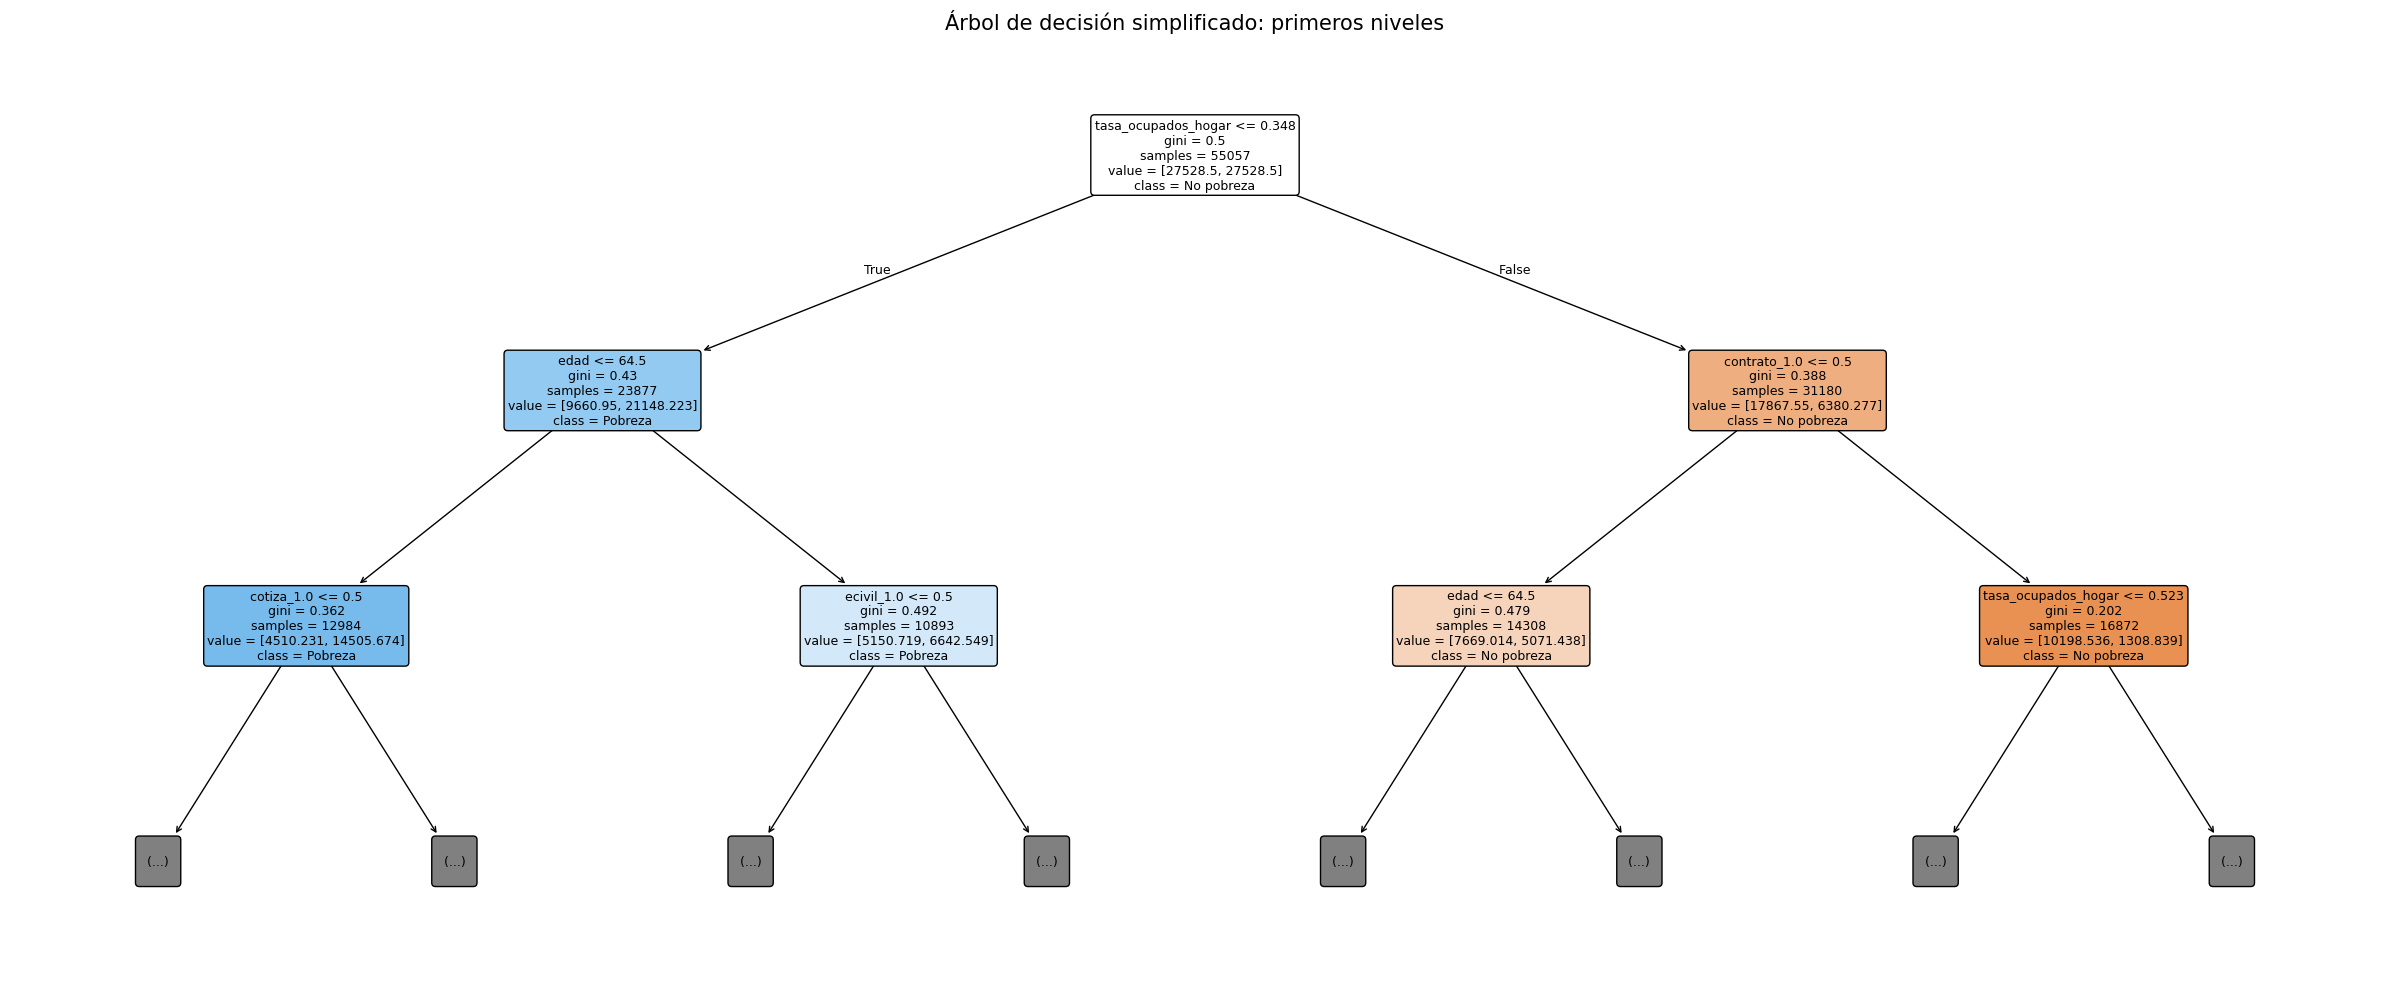

In [20]:
# ============================================================
# BLOQUE 19: Visualización parcial del árbol de decisión
# ============================================================

# Función para graficar árboles de decisión
from sklearn.tree import plot_tree

# ------------------------------------------------------------
# 1. Extraer árbol entrenado y preprocesador
# ------------------------------------------------------------

# Se extrae el árbol ya ajustado desde el pipeline
arbol_final = modelo_arbol_decision.named_steps["modelo"]

# Se extrae el preprocesador usado antes del modelo
preprocesador_arbol = modelo_arbol_decision.named_steps["preprocesamiento"]

# ------------------------------------------------------------
# 2. Recuperar nombres de variables después del preprocesamiento
# ------------------------------------------------------------

# Nombres de variables numéricas
nombres_numericas_arbol = variables_numericas_arboles

# Se extrae el codificador One Hot aplicado a las variables categóricas
ohe_arbol = preprocesador_arbol.named_transformers_["categoricas"]

# Nombres de las variables categóricas luego de la codificación
nombres_categoricas_arbol = list(
    ohe_arbol.get_feature_names_out(variables_categoricas_arboles)
)

# Lista final de variables usadas por el árbol
nombres_variables_arbol = nombres_numericas_arbol + nombres_categoricas_arbol

# ------------------------------------------------------------
# 3. Graficar solo los primeros niveles del árbol
# ------------------------------------------------------------

plt.figure(figsize=(24, 10))

plot_tree(
    arbol_final,
    feature_names=nombres_variables_arbol,
    class_names=["No pobreza", "Pobreza"],
    max_depth=2,          # Se muestran solo los primeros niveles para facilitar la lectura
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Árbol de decisión simplificado: primeros niveles", fontsize=15)
plt.tight_layout()
plt.show()

## 7. Random Forest ajustado

Se ajustan hiperparámetros del Random Forest mediante Grid Search con validación cruzada. La búsqueda se realiza con una grilla acotada para mejorar el modelo sin aumentar demasiado el costo computacional.


In [21]:
# ============================================================
# BLOQUE 20: Ajuste de hiperparámetros del Random Forest
# ============================================================

# Herramientas para búsqueda de hiperparámetros y validación cruzada
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# ------------------------------------------------------------
# 1. Modelo base para búsqueda
# ------------------------------------------------------------

# Pipeline base del Random Forest para probar distintas combinaciones
rf_busqueda = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento_arboles),
        ("modelo", RandomForestClassifier(
            random_state=SEED,
            n_jobs=-1
        ))
    ]
)

# ------------------------------------------------------------
# 2. Grilla pequeña de hiperparámetros
# ------------------------------------------------------------

# Se define una grilla acotada para comparar combinaciones razonables
param_grid_rf = {
    "modelo__n_estimators": [200, 300],
    "modelo__max_depth": [10, 12, 14],
    "modelo__min_samples_leaf": [30, 50],
    "modelo__max_features": ["sqrt", "log2"],
    "modelo__class_weight": ["balanced_subsample"]
}

# ------------------------------------------------------------
# 3. Validación cruzada
# ------------------------------------------------------------

# Validación cruzada estratificada para mantener la proporción de clases
cv_rf_tuning = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

# Métricas evaluadas durante la búsqueda
scoring_rf = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

# ------------------------------------------------------------
# 4. Búsqueda de hiperparámetros
# ------------------------------------------------------------

# Se usa F1-score como métrica principal para seleccionar el mejor modelo
grid_rf = GridSearchCV(
    estimator=rf_busqueda,
    param_grid=param_grid_rf,
    scoring=scoring_rf,
    refit="f1",
    cv=cv_rf_tuning,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

# Ajuste de la búsqueda usando el conjunto de entrenamiento
grid_rf.fit(X_train_arboles, y_train)

# ------------------------------------------------------------
# 5. Mejores hiperparámetros
# ------------------------------------------------------------

# Se muestran los mejores hiperparámetros encontrados
print("MEJORES HIPERPARÁMETROS RANDOM FOREST")
print("="*70)
print(grid_rf.best_params_)

print("\nMejor F1 promedio en validación cruzada:")
print(round(grid_rf.best_score_, 4))

# ------------------------------------------------------------
# 6. Resultados de la búsqueda
# ------------------------------------------------------------

# Se extraen todos los resultados del Grid Search
resultados_grid_rf = pd.DataFrame(grid_rf.cv_results_)

# Columnas principales para revisar las mejores combinaciones
columnas_resultados_rf = [
    "param_modelo__n_estimators",
    "param_modelo__max_depth",
    "param_modelo__min_samples_leaf",
    "param_modelo__max_features",
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_roc_auc",
    "mean_test_pr_auc"
]

tabla_grid_rf = resultados_grid_rf[columnas_resultados_rf].copy()

# Se ordenan los resultados según F1 promedio
tabla_grid_rf = tabla_grid_rf.sort_values(
    "mean_test_f1",
    ascending=False
).reset_index(drop=True)

# Redondeo de métricas para facilitar la lectura
for col in [
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_roc_auc",
    "mean_test_pr_auc"
]:
    tabla_grid_rf[col] = tabla_grid_rf[col].round(3)

# Se muestran las mejores combinaciones encontradas
print("\nMEJORES COMBINACIONES SEGÚN F1")
print("="*70)
display(tabla_grid_rf.head(10))

# ------------------------------------------------------------
# 7. Evaluación del mejor Random Forest en el conjunto test
# ------------------------------------------------------------

# Se recupera el mejor modelo encontrado por Grid Search
modelo_random_forest_ajustado = grid_rf.best_estimator_

# Predicciones del modelo ajustado en el conjunto de prueba
y_pred_rf_ajustado = modelo_random_forest_ajustado.predict(X_test_arboles)
y_prob_rf_ajustado = modelo_random_forest_ajustado.predict_proba(X_test_arboles)[:, 1]

# Métricas del Random Forest ajustado
metricas_rf_ajustado = calcular_metricas_clasificacion(
    "Random Forest ajustado",
    y_test,
    y_pred_rf_ajustado,
    y_prob_rf_ajustado,
    len(variables_modelos_arboles)
)

# ------------------------------------------------------------
# 8. Comparación Random Forest inicial vs ajustado
# ------------------------------------------------------------

# Comparación entre el modelo inicial y el modelo con hiperparámetros ajustados
tabla_comparacion_rf_ajuste = pd.DataFrame([
    metricas_rf,
    metricas_rf_ajustado
])

# Redondeo de métricas
for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]:
    tabla_comparacion_rf_ajuste[col] = tabla_comparacion_rf_ajuste[col].round(3)

print("\nCOMPARACIÓN RANDOM FOREST INICIAL VS AJUSTADO")
print("="*70)
display(tabla_comparacion_rf_ajuste)

# ------------------------------------------------------------
# 9. Matriz de confusión del Random Forest ajustado
# ------------------------------------------------------------

# Matriz de confusión del modelo ajustado
matriz_rf_ajustado = pd.DataFrame(
    confusion_matrix(y_test, y_pred_rf_ajustado),
    index=["Real: No pobreza", "Real: Pobreza"],
    columns=["Predicho: No pobreza", "Predicho: Pobreza"]
)

print("\nMATRIZ DE CONFUSIÓN - RANDOM FOREST AJUSTADO")
print("="*70)
display(matriz_rf_ajustado)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
MEJORES HIPERPARÁMETROS RANDOM FOREST
{'modelo__class_weight': 'balanced_subsample', 'modelo__max_depth': 14, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 30, 'modelo__n_estimators': 300}

Mejor F1 promedio en validación cruzada:
0.5759

MEJORES COMBINACIONES SEGÚN F1


,param_modelo__n_estimators,param_modelo__max_depth,param_modelo__min_samples_leaf,param_modelo__max_features,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,mean_test_pr_auc
0,300,14,30,sqrt,0.767,0.451,0.798,0.576,0.860,0.607
1,200,14,30,sqrt,0.767,0.451,0.797,0.576,0.860,0.606
2,300,12,30,sqrt,0.766,0.449,0.798,0.575,0.859,0.605
3,200,12,30,sqrt,0.766,0.449,0.798,0.575,0.859,0.605
4,300,10,30,sqrt,0.763,0.445,0.796,0.571,0.856,0.601
5,200,10,30,sqrt,0.763,0.445,0.795,0.571,0.856,0.601
6,300,14,50,sqrt,0.761,0.443,0.801,0.570,0.857,0.601
7,200,14,50,sqrt,0.760,0.442,0.803,0.570,0.857,0.600
8,300,12,50,sqrt,0.760,0.442,0.802,0.570,0.856,0.600
9,200,12,50,sqrt,0.760,0.442,0.801,0.570,0.856,0.599



COMPARACIÓN RANDOM FOREST INICIAL VS AJUSTADO


,modelo,n_variables_originales,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Random Forest,25,0.760,0.443,0.816,0.574,0.860,0.611
1,Random Forest ajustado,25,0.769,0.454,0.813,0.582,0.863,0.617



MATRIZ DE CONFUSIÓN - RANDOM FOREST AJUSTADO


,Predicho: No pobreza,Predicho: Pobreza
Real: No pobreza,14337,4581
Real: Pobreza,876,3803


El ajuste de hiperparámetros permite comparar si el Random Forest mejora respecto a su versión inicial. La decisión se apoya principalmente en F1-score, sin dejar de revisar métricas como recall, ROC-AUC y PR-AUC.


## 8. Comparación final e interpretación del modelo final

En este bloque se realiza la comparación final entre los principales modelos evaluados. Se consideran métricas generales y curvas ROC y Precision-Recall para apoyar la selección del modelo más adecuado.


COMPARACIÓN FINAL ACTUALIZADA DE MODELOS


,modelo,n_variables_originales,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logística balanceada completa,25,0.759,0.440,0.779,0.562,0.849,0.583
1,Logística parsimoniosa extendida,5,0.714,0.387,0.759,0.512,0.807,0.527
2,Árbol de decisión,25,0.726,0.407,0.830,0.546,0.843,0.555
3,Random Forest ajustado,25,0.769,0.454,0.813,0.582,0.863,0.617


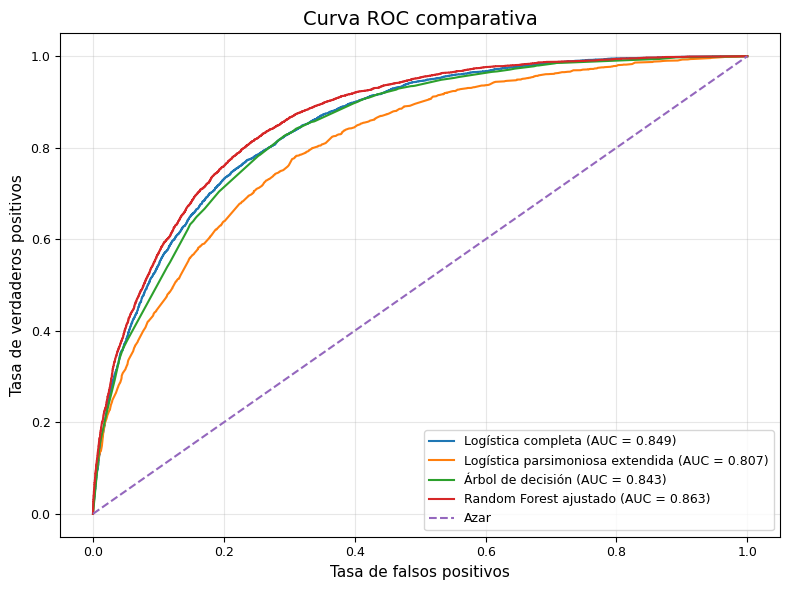

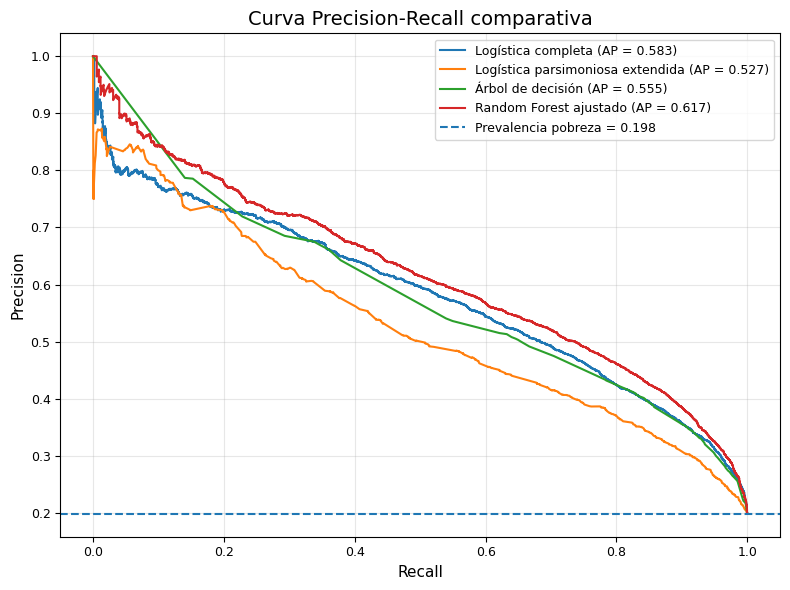

RESUMEN FINAL ACTUALIZADO
Mejor modelo según F1-score: Random Forest ajustado (0.582)
Mejor modelo según ROC-AUC: Random Forest ajustado (0.863)
Mejor modelo según PR-AUC: Random Forest ajustado (0.617)


In [22]:
# ============================================================
# BLOQUE 21: Comparación final actualizada de modelos
# ============================================================

# Funciones para construir curvas ROC y Precision-Recall
from sklearn.metrics import roc_curve, precision_recall_curve

# ------------------------------------------------------------
# 1. Tabla final actualizada
# ------------------------------------------------------------

# Se reúnen las métricas de los modelos principales
tabla_comparacion_final_ajustada = pd.DataFrame([
    metricas_completo,
    metricas_extendido,
    metricas_arbol,
    metricas_rf_ajustado
])

# Columnas que se mostrarán en la comparación final
columnas_finales = [
    "modelo",
    "n_variables_originales",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc"
]

tabla_comparacion_final_ajustada = tabla_comparacion_final_ajustada[columnas_finales]

# Redondeo de métricas
for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]:
    tabla_comparacion_final_ajustada[col] = tabla_comparacion_final_ajustada[col].round(3)

print("COMPARACIÓN FINAL ACTUALIZADA DE MODELOS")
print("="*70)
display(tabla_comparacion_final_ajustada)

# ------------------------------------------------------------
# 2. Probabilidades estimadas de cada modelo
# ------------------------------------------------------------

# Diccionario para guardar las probabilidades estimadas por cada modelo
modelos_probabilidades_final = {}

# Probabilidades de la regresión logística completa
if "y_prob_interpretacion" in globals():
    modelos_probabilidades_final["Logística completa"] = y_prob_interpretacion
elif "y_prob_balanceado" in globals():
    modelos_probabilidades_final["Logística completa"] = y_prob_balanceado

# Probabilidades de los demás modelos evaluados
modelos_probabilidades_final["Logística parsimoniosa extendida"] = y_prob_extendido
modelos_probabilidades_final["Árbol de decisión"] = y_prob_arbol
modelos_probabilidades_final["Random Forest ajustado"] = y_prob_rf_ajustado

# ------------------------------------------------------------
# 3. Curva ROC comparativa actualizada
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

# Se grafica la curva ROC de cada modelo
for nombre_modelo, y_prob in modelos_probabilidades_final.items():

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_modelo = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{nombre_modelo} (AUC = {auc_modelo:.3f})"
    )

# Línea de referencia asociada a clasificación al azar
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Azar"
)

plt.title("Curva ROC comparativa", fontsize=14)
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Curva Precision-Recall comparativa actualizada
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

# Se grafica la curva Precision-Recall de cada modelo
for nombre_modelo, y_prob in modelos_probabilidades_final.items():

    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
    ap_modelo = average_precision_score(y_test, y_prob)

    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{nombre_modelo} (AP = {ap_modelo:.3f})"
    )

# Línea de referencia correspondiente a la prevalencia de pobreza en test
prevalencia_pobreza = y_test.mean()

plt.axhline(
    prevalencia_pobreza,
    linestyle="--",
    label=f"Prevalencia pobreza = {prevalencia_pobreza:.3f}"
)

plt.title("Curva Precision-Recall comparativa", fontsize=14)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Resumen final actualizado
# ------------------------------------------------------------

# Se identifica el mejor modelo según distintas métricas
mejor_f1 = tabla_comparacion_final_ajustada.sort_values(
    "f1_score",
    ascending=False
).iloc[0]

mejor_auc = tabla_comparacion_final_ajustada.sort_values(
    "roc_auc",
    ascending=False
).iloc[0]

mejor_pr_auc = tabla_comparacion_final_ajustada.sort_values(
    "pr_auc",
    ascending=False
).iloc[0]

print("RESUMEN FINAL ACTUALIZADO")
print("="*70)
print(f"Mejor modelo según F1-score: {mejor_f1['modelo']} ({mejor_f1['f1_score']})")
print(f"Mejor modelo según ROC-AUC: {mejor_auc['modelo']} ({mejor_auc['roc_auc']})")
print(f"Mejor modelo según PR-AUC: {mejor_pr_auc['modelo']} ({mejor_pr_auc['pr_auc']})")

La comparación final permite identificar qué modelo presenta mejor desempeño según distintas métricas. La decisión no debe basarse solo en accuracy, sino también en F1-score y PR-AUC, ya que la clase de pobreza tiene menor representación.


Como el Random Forest ajustado fue el modelo seleccionado por sus métricas, en este bloque se revisa la importancia de sus variables. Esto permite identificar cuáles variables tuvieron mayor peso dentro del proceso de clasificación.


IMPORTANCIA DE VARIABLES TRANSFORMADAS - RANDOM FOREST AJUSTADO


,variable_transformada,importancia,importancia_pct
0,tasa_ocupados_hogar,0.246,24.581
1,edad,0.066,6.631
2,contrato_1.0,0.059,5.915
3,esc,0.058,5.788
4,cotiza_0.0,0.056,5.645
5,cotiza_1.0,0.054,5.417
6,tasa_inactivos_hogar,0.043,4.309
7,contrato_2.0,0.037,3.684
8,activ_1.0,0.030,3.009
9,numper,0.026,2.614



IMPORTANCIA AGRUPADA POR VARIABLE ORIGINAL - RANDOM FOREST AJUSTADO


,variable_original,importancia,importancia_pct
0,tasa_ocupados_hogar,0.246,24.581
1,cotiza,0.111,11.061
2,contrato,0.102,10.191
3,edad,0.066,6.631
4,esc,0.058,5.788
5,activ,0.049,4.934
6,tipohogar,0.046,4.599
7,may60c,0.045,4.531
8,tasa_inactivos_hogar,0.043,4.309
9,men18c,0.037,3.703


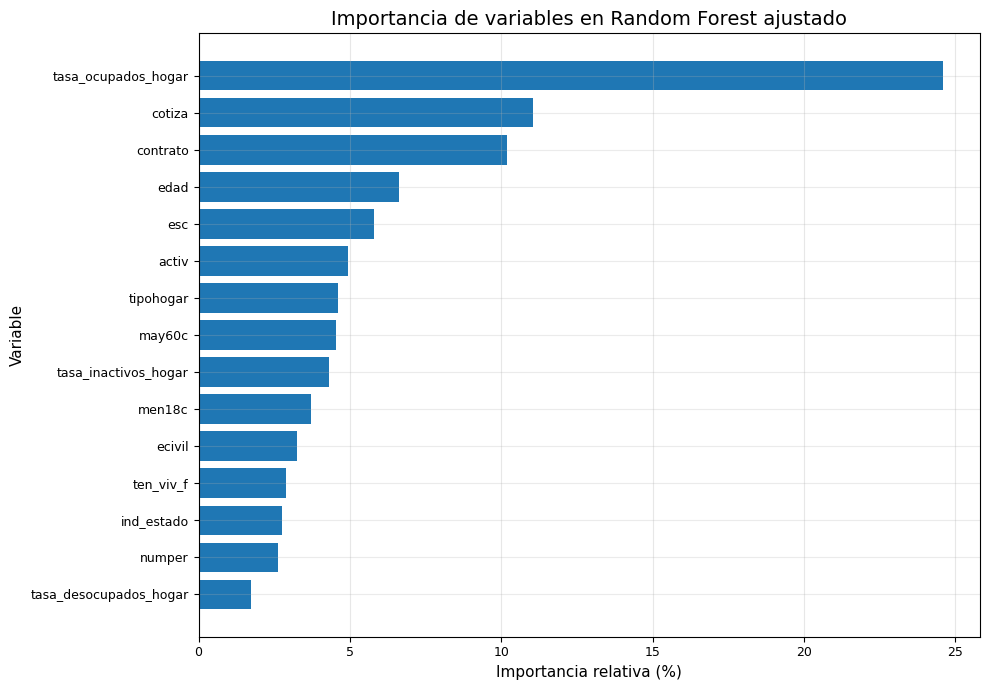


VARIABLES MÁS IMPORTANTES SEGÚN RANDOM FOREST AJUSTADO
1. tasa_ocupados_hogar: 24.58%
2. cotiza: 11.06%
3. contrato: 10.19%
4. edad: 6.63%
5. esc: 5.79%
6. activ: 4.93%
7. tipohogar: 4.60%
8. may60c: 4.53%
9. tasa_inactivos_hogar: 4.31%
10. men18c: 3.70%


In [23]:
# ============================================================
# BLOQUE 22: Importancia de variables del Random Forest ajustado
# ============================================================

# ------------------------------------------------------------
# 1. Extraer modelo ajustado y preprocesador
# ------------------------------------------------------------

# Se extrae el modelo Random Forest ya ajustado desde el pipeline
rf_ajustado_final = modelo_random_forest_ajustado.named_steps["modelo"]

# Se extrae el preprocesador usado antes del modelo
preprocesador_rf_ajustado = modelo_random_forest_ajustado.named_steps["preprocesamiento"]

# ------------------------------------------------------------
# 2. Recuperar nombres de variables transformadas
# ------------------------------------------------------------

# Variables numéricas usadas directamente por el modelo
nombres_numericas_rf_ajustado = variables_numericas_arboles

# Se extrae el codificador de variables categóricas
ohe_rf_ajustado = preprocesador_rf_ajustado.named_transformers_["categoricas"]

# Nombres de variables categóricas después del One Hot Encoding
nombres_categoricas_rf_ajustado = list(
    ohe_rf_ajustado.get_feature_names_out(variables_categoricas_arboles)
)

# Lista final de variables transformadas usadas por el Random Forest
nombres_variables_rf_ajustado = (
    nombres_numericas_rf_ajustado +
    nombres_categoricas_rf_ajustado
)

# ------------------------------------------------------------
# 3. Importancia a nivel de variable transformada
# ------------------------------------------------------------

# Se construye una tabla con la importancia entregada por el modelo
tabla_importancia_rf_ajustado = pd.DataFrame({
    "variable_transformada": nombres_variables_rf_ajustado,
    "importancia": rf_ajustado_final.feature_importances_
})

# Se ordenan las variables desde la más importante a la menos importante
tabla_importancia_rf_ajustado = tabla_importancia_rf_ajustado.sort_values(
    "importancia",
    ascending=False
).reset_index(drop=True)

# Se calcula la importancia relativa en porcentaje
tabla_importancia_rf_ajustado["importancia_pct"] = (
    100 *
    tabla_importancia_rf_ajustado["importancia"] /
    tabla_importancia_rf_ajustado["importancia"].sum()
)

print("IMPORTANCIA DE VARIABLES TRANSFORMADAS - RANDOM FOREST AJUSTADO")
print("="*70)

# Se muestran las 20 variables transformadas más importantes
display(
    tabla_importancia_rf_ajustado.head(20).round(4)
)

# ------------------------------------------------------------
# 4. Recuperar variable original
# ------------------------------------------------------------

# Función para asociar cada variable transformada con su variable original
def obtener_variable_original_rf(nombre_variable):

    if nombre_variable in variables_numericas_arboles:
        return nombre_variable

    for var in variables_categoricas_arboles:
        if nombre_variable.startswith(var + "_"):
            return var

    return nombre_variable

# Se agrega la variable original correspondiente
tabla_importancia_rf_ajustado["variable_original"] = tabla_importancia_rf_ajustado[
    "variable_transformada"
].apply(obtener_variable_original_rf)

# ------------------------------------------------------------
# 5. Importancia agrupada por variable original
# ------------------------------------------------------------

# Se agrupa la importancia de las categorías creadas por One Hot Encoding
tabla_importancia_original_rf_ajustado = (
    tabla_importancia_rf_ajustado
    .groupby("variable_original", as_index=False)
    .agg(importancia=("importancia", "sum"))
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

# Se calcula la importancia relativa agrupada
tabla_importancia_original_rf_ajustado["importancia_pct"] = (
    100 *
    tabla_importancia_original_rf_ajustado["importancia"] /
    tabla_importancia_original_rf_ajustado["importancia"].sum()
)

print("\nIMPORTANCIA AGRUPADA POR VARIABLE ORIGINAL - RANDOM FOREST AJUSTADO")
print("="*70)

display(
    tabla_importancia_original_rf_ajustado.round(4)
)

# ------------------------------------------------------------
# 6. Gráfico de importancia por variable original
# ------------------------------------------------------------

# Cantidad de variables a mostrar en el gráfico
top_n = 15

# Se seleccionan las variables más importantes
tabla_grafico_rf_ajustado = tabla_importancia_original_rf_ajustado.head(top_n).copy()
tabla_grafico_rf_ajustado = tabla_grafico_rf_ajustado.sort_values(
    "importancia_pct",
    ascending=True
)

# Gráfico de barras horizontales
plt.figure(figsize=(10, 7))

plt.barh(
    tabla_grafico_rf_ajustado["variable_original"],
    tabla_grafico_rf_ajustado["importancia_pct"]
)

plt.title("Importancia de variables en Random Forest ajustado", fontsize=14)
plt.xlabel("Importancia relativa (%)")
plt.ylabel("Variable")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Variables más importantes
# ------------------------------------------------------------

# Se imprimen las 10 variables con mayor importancia relativa
print("\nVARIABLES MÁS IMPORTANTES SEGÚN RANDOM FOREST AJUSTADO")
print("="*70)

for i, fila in tabla_importancia_original_rf_ajustado.head(10).iterrows():
    print(
        f"{i+1}. {fila['variable_original']}: "
        f"{fila['importancia_pct']:.2f}%"
    )

La importancia de variables muestra qué atributos fueron más utilizados por el Random Forest ajustado para clasificar los hogares. Esta interpretación es útil para describir el modelo seleccionado, aunque no debe entenderse como una relación causal.


## 9. Síntesis final

En este bloque se presenta una síntesis final del proceso de modelamiento, resumiendo el tipo de problema, los modelos evaluados, el modelo seleccionado y las principales variables destacadas.


In [24]:
# ============================================================
# BLOQUE 23: Síntesis final del modelamiento
# ============================================================

# Se imprime un resumen general del proceso de modelamiento
print("SÍNTESIS FINAL DEL MODELAMIENTO")
print("=" * 80)

# Tipo de problema trabajado
print("\n1. Tipo de problema")
print("- Clasificación binaria supervisada.")
print("- Variable objetivo: pobreza_ingresos.")
print("- Clase positiva: hogares en pobreza por ingresos.")

# Modelos considerados durante el análisis
print("\n2. Modelos evaluados")
print("- Regresión logística balanceada completa: modelo interpretable.")
print("- Regresión logística parsimoniosa extendida: comparación de parsimonia.")
print("- Árbol de decisión: modelo no lineal simple de referencia.")
print("- Random Forest ajustado: modelo predictivo final.")

# Modelo seleccionado según las métricas evaluadas
print("\n3. Mejor modelo predictivo")
print("- Random Forest ajustado.")
print(f"- Accuracy: {metricas_rf_ajustado['accuracy']:.3f}")
print(f"- Precision: {metricas_rf_ajustado['precision']:.3f}")
print(f"- Recall: {metricas_rf_ajustado['recall']:.3f}")
print(f"- F1-score: {metricas_rf_ajustado['f1_score']:.3f}")
print(f"- ROC-AUC: {metricas_rf_ajustado['roc_auc']:.3f}")
print(f"- PR-AUC: {metricas_rf_ajustado['pr_auc']:.3f}")

# Modelo utilizado principalmente para interpretación
print("\n4. Modelo interpretable principal")
print("- Regresión logística balanceada completa.")
print("- Se usa para interpretar dirección de asociación mediante betas y odds ratios.")

# Variables más importantes según el Random Forest ajustado
print("\n5. Variables destacadas en Random Forest ajustado")
for i, fila in tabla_importancia_original_rf_ajustado.head(10).iterrows():
    print(f"- {fila['variable_original']}: {fila['importancia_pct']:.2f}%")

# Aclaración sobre el alcance de los resultados
print("\n6. Advertencia")
print("- Los resultados corresponden a asociaciones predictivas, no causales.")
print("- La importancia del Random Forest indica aporte predictivo, no dirección del efecto.")

SÍNTESIS FINAL DEL MODELAMIENTO

1. Tipo de problema
- Clasificación binaria supervisada.
- Variable objetivo: pobreza_ingresos.
- Clase positiva: hogares en pobreza por ingresos.

2. Modelos evaluados
- Regresión logística balanceada completa: modelo interpretable.
- Regresión logística parsimoniosa extendida: comparación de parsimonia.
- Árbol de decisión: modelo no lineal simple de referencia.
- Random Forest ajustado: modelo predictivo final.

3. Mejor modelo predictivo
- Random Forest ajustado.
- Accuracy: 0.769
- Precision: 0.454
- Recall: 0.813
- F1-score: 0.582
- ROC-AUC: 0.863
- PR-AUC: 0.617

4. Modelo interpretable principal
- Regresión logística balanceada completa.
- Se usa para interpretar dirección de asociación mediante betas y odds ratios.

5. Variables destacadas en Random Forest ajustado
- tasa_ocupados_hogar: 24.58%
- cotiza: 11.06%
- contrato: 10.19%
- edad: 6.63%
- esc: 5.79%
- activ: 4.93%
- tipohogar: 4.60%
- may60c: 4.53%
- tasa_inactivos_hogar: 4.31%
- men18c: